<div style=" border-bottom: 8px solid #e3f56c; overflow: hidden; border-radius: 10px; height: 95%; width: 100%; display: flex;">
  <div style="height: 100%; width: 100%; background-color: #3800BB; float: left; text-align: center; display: flex; justify-content: left; align-items: center; font-size: 40px; ">
    <b><span style="color: #FFFFFF; padding: 20px 20px;">Santander Customer Satisfaction: EDA</span></b>
  </div>
</div>

<div class="alert" style="background-color: #FFFFFF; border-left: 8px solid #B12111; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **This notebook performs Exploratory Data Analysis for the [Santander Customer Satisfaction competition](https://www.kaggle.com/c/santander-customer-satisfaction/overview).**

**The main steps include:**

<div class="alert alert-danger">

**Workflow Overview**
</div>


1. **Import Libraries and Setup**: Load required Python libraries and configure the environment.
2. **Load Data**: Read the interim training and test datasets from CSV files (from ../data/interim).
3. **Data Overview**: Check shape and cross-check results of previous working notebook on completeness of interim dataset (missing values).
4. **Finding Categorical Features**: Assuming certain numeric features to be categorical.
5. **Assuming Interval Features**: All features - "those, that are taken as categorical"
6. **Outliers**: Overview + new feature: if has_outliers => 1 else => 0
7. **Calculating Phik Correlation**: Phik Correlation + Visulization
8. **Visual Analysis**: Visualize features' distribution in different ways + target concentration
    - Feature-wise class-normalized density distribution (Histogram-based)
    - Feature-wise class-normalized density distribution (KDE-based)
    - Feature-wise class-normalized distribution analysis (equal-width-binning-based)
    - Feature-wise class-normalized distribution analysis (quantile-binning-based)
    - Categorical feature-wise target structure by value
9. **Reviewing categorical features**: Calculate Target Concentration and review features
10. **Reviewing categorical features - Automated**: Review features using custom function from `data_utils.FeaturesUtils.feature_usefulness_report`
- **Conclusion**



<div class="alert alert-danger">

**Key Functions and Steps**
</div>

- `data_utils.load_data`: Loads CSV data into a pandas DataFrame.
- `data_utils.find_categorical_candidates`: Function that allows assuming certain numeric features to be categorical.
- `data_utils.intersect_features`: Ensures feature consistency between train and test sets.
- `feature_usefulness_report`: Generates a report on the usefulness of categorical features based on heuristics.


<div class="alert alert-danger">

**Outputs**
</div>

- Data understanding and knowledge
- Visual representations of feature and target distributions
- Identification of useful, potentially helpful, and redundant (droppable) features — prior to model building
- Reports summarizing the above points (including reusable pickle files)

</div>

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **Import Libraries and Setup**

</div>

In [1]:
import sys
import os
# Add the parent directory to the Python path
sys.path.append(os.path.abspath('..'))


from src.data.data_utils import (
    setup_logging,
    load_data,
    # initial_cleaning,
    intersect_features,
    # find_categorical_candidates,
)
from src.data.data_utils import FeaturesUtils
setup_logging("02_eda.log")


import pickle
from classes import Paths
import pandas as pd
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", None)
import numpy as np
import warnings
warnings.filterwarnings("ignore")


import scipy
import scipy.stats
from matplotlib import pyplot as plt
import math
import seaborn as sns
import phik
from phik.report import plot_correlation_matrix
from phik import report
from IPython.display import display, HTML

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **Load Data**

</div>

In [2]:
paths = Paths()
# Load the data
df_train = load_data(paths.get_interim_data_path("train_cleaned.csv"))
df_test = load_data(paths.get_interim_data_path("test_cleaned.csv"))
df_train.head()

,Unnamed: 0,imp_op_var41_comer_ult3,num_var13_largo_0,num_var32,imp_op_var39_ult1,imp_aport_var17_ult1,ind_var37_cte,delta_num_aport_var17_1y3,num_var37_med_ult2,imp_reemb_var13_ult1,ind_var24,num_var43_recib_ult1,imp_trans_var37_ult1,num_var40,num_var45_ult3,delta_imp_amort_var34_1y3,imp_trasp_var33_in_ult1,imp_op_var40_ult1,num_trasp_var11_ult1,ind_var26_0,num_var20_0,saldo_var29,imp_aport_var17_hace3,ind_var24_0,num_var13_corto_0,saldo_medio_var13_corto_hace3,delta_imp_reemb_var17_1y3,imp_trasp_var33_out_ult1,var15,num_var31_0,ind_var12,ind_var13_0,saldo_medio_var12_hace3,num_op_var39_comer_ult3,num_var31,saldo_var18,imp_reemb_var33_ult1,num_op_var39_ult3,imp_aport_var13_hace3,saldo_medio_var13_largo_hace3,num_aport_var13_ult1,num_var7_recib_ult1,delta_imp_venta_var44_1y3,imp_var7_emit_ult1,num_op_var41_efect_ult1,num_var25_0,num_op_var40_efect_ult1,saldo_medio_var8_ult1,imp_amort_var34_ult1,num_op_var41_comer_ult1,num_op_var39_hace2,delta_num_aport_var33_1y3,ind_var13_largo_0,saldo_medio_var13_medio_ult3,ind_var26_cte,num_var30_0,num_var41_0,delta_imp_compra_var44_1y3,saldo_medio_var44_ult3,num_op_var40_hace2,saldo_var8,saldo_medio_var13_largo_hace2,num_var45_hace2,imp_reemb_var17_ult1,saldo_var40,num_op_var39_ult1,ind_var41_0,num_op_var40_ult3,num_var22_ult3,imp_sal_var16_ult1,num_var35,imp_aport_var13_ult1,num_var17_0,saldo_medio_var33_hace2,ID,num_var14,delta_imp_aport_var13_1y3,ind_var43_emit_ult1,num_var14_0,num_aport_var17_ult1,var21,num_var42,num_var5,ind_var37_0,saldo_var13_corto,saldo_var37,num_op_var40_comer_ult1,num_op_var41_hace3,delta_num_reemb_var13_1y3,imp_reemb_var17_hace3,delta_imp_amort_var18_1y3,num_var30,ind_var12_0,imp_op_var39_efect_ult1,num_var44,imp_var43_emit_ult1,num_meses_var13_largo_ult3,delta_imp_trasp_var17_in_1y3,saldo_medio_var12_hace2,imp_compra_var44_hace3,num_venta_var44_ult1,saldo_medio_var29_hace2,saldo_var13_largo,ind_var43_recib_ult1,num_meses_var39_vig_ult3,saldo_medio_var5_ult1,num_var8_0,saldo_var26,num_var22_ult1,num_var17,imp_trasp_var17_in_hace3,saldo_var32,ind_var1_0,num_meses_var5_ult3,var3,imp_op_var40_efect_ult3,saldo_medio_var29_hace3,saldo_var33,saldo_medio_var5_hace2,imp_op_var40_comer_ult3,imp_var7_recib_ult1,num_sal_var16_ult1,saldo_var42,imp_op_var40_comer_ult1,var36,saldo_medio_var13_largo_ult3,saldo_var5,delta_num_trasp_var33_in_1y3,ind_var5_0,num_var37_0,num_var45_hace3,saldo_var30,ind_var8,imp_venta_var44_hace3,num_aport_var17_hace3,num_op_var41_efect_ult3,num_var5_0,delta_imp_trasp_var17_out_1y3,num_var42_0,var38,num_op_var40_efect_ult3,saldo_medio_var13_corto_hace2,ind_var10_ult1,saldo_var14,num_var12_0,num_var44_0,imp_aport_var33_ult1,imp_op_var39_efect_ult3,num_var22_hace3,imp_op_var39_comer_ult1,num_meses_var8_ult3,num_compra_var44_ult1,num_var22_hace2,num_var20,num_op_var40_hace3,saldo_medio_var29_ult3,saldo_medio_var33_hace3,imp_trasp_var17_out_ult1,ind_var9_cte_ult1,imp_ent_var16_ult1,num_aport_var13_hace3,ind_var14_0,imp_trasp_var33_in_hace3,num_ent_var16_ult1,saldo_medio_var5_ult3,num_var33_0,imp_trasp_var17_in_ult1,saldo_medio_var44_hace2,ind_var30,num_var45_ult1,num_var43_emit_ult1,saldo_medio_var8_hace2,imp_venta_var44_ult1,saldo_medio_var8_hace3,imp_op_var40_efect_ult1,saldo_var13,saldo_var20,saldo_medio_var5_hace3,saldo_medio_var44_hace3,saldo_medio_var8_ult3,saldo_var44,num_op_var40_comer_ult3,num_med_var22_ult3,imp_aport_var33_hace3,TARGET
0,0,0.00,0,0,0.00,0.00,0,0.00,0,0.00,0,0,0.00,0,0,0,0.00,0.00,0,0,0,0.00,0.00,0,0,0.00,0,0,23,0,0,0,0.00,0,0,0,0,0,0.00,0.00,0,0,0.00,0.00,0,0,0,0.00,0.00,0,0,0.00,0,0.00,0,3,3,0.00,0.00,0,0.00,0.00,0,0.00,0.00,0,1,0,0,0.00,0,0.00,0,0.00,1,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0,0,0,0.00,0,0,0,0.00,0,0.00,0,0,0.00,0.00,0,0.00,0.00,0,2,0.00,0,0.00,0,0,0.00,0.00,0,0,2,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,0.00,99,0.00,0.00,0,1,0,0,0.00,0,0.00,0,0,3,0,3,"39,205.17",0,0.00,0,0.00,0,0,0,0.00,0,0.00,0,0,0,0,0,0.00,0.00,0.00,0,0.00,0,0,0.00,0,0.00,0,0.00,0.00,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0,0,0
1,1,0

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **Data Overview**

</div>

In [3]:
# shape
df_train.shape

df_test.shape

(75818, 184)

In [4]:
df_train.__assigned_df_name__ = "df_train"
df_test.__assigned_df_name__ = "df_test"

for i_df in [df_train, df_test]:
    tmp_unique_dtypes = []
    for col in i_df.columns:
        tmp_unique_dtypes.append(str(i_df[col].dtype))
    print(f"Shape of {i_df.__assigned_df_name__}: {i_df.shape}")  # shape
    print("Missing values:", i_df.isna().any().sum())   # missing values
    print(f"Data types in {i_df.__assigned_df_name__}: {set(tmp_unique_dtypes)}")

del i_df, tmp_unique_dtypes

Shape of df_train: (76020, 185)
Missing values: 0
Data types in df_train: {'float64', 'int64'}
Shape of df_test: (75818, 184)
Missing values: 0
Data types in df_test: {'float64', 'int64'}


<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **Finding Categorical Features**

</div>

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

Dataframes have no missing values and datatypes are int64 and float64
</div>

<div class="alert" style="background-color:rgb(255, 255, 255); border-left: 8px solid #B12111; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

Identifies potential categorical columns in the DataFrame based on unique value counts.
Logs the number of candidates found.

Parameters:
- df_train: DataFrame to analyze.
- threshold: Maximum ratio of unique values to total rows to consider a column categorical.
- max_unique_values: Maximum number of unique values for a column to be considered categorical.

Returns:
- List of column names that are potential categorical candidates.
</div>

<div class="alert" style="background-color:rgb(0, 0, 0); border-left: 8px solid #B12111; padding: 14px; border-radius: 8px; font-size: 14px; color:rgb(255, 255, 255);">

```python
def find_categorical_candidates(df_train, threshold=0.05, max_unique_values=50):
    n_rows = df_train.shape[0]
    categorical_candidates = []

    tmp = max_unique_values / n_rows
    if tmp < threshold:
        threshold = tmp
        print(f"Threshold adjusted to {threshold*100:.2f}% based on max_unique_values {max_unique_values} and number of rows {n_rows}")

    # Iterate through each column in the DataFrame

    for col in df_train.columns:
        if df_train[col].dtype in ['int64', 'float64']:
            n_unique = df_train[col].nunique(dropna=True)
            unique_ratio = n_unique / n_rows

            if n_unique <= max_unique_values or unique_ratio < threshold:
                categorical_candidates.append(col)

    return categorical_candidates
```

</div>

In [5]:
for j in [20, 25, 27, 30, 40, 50, 60]:
    categorical_cols = FeaturesUtils.find_categorical_candidates(df_train, max_unique_values=j)
    print(f"Max unique values: {j}, Number of possible categorical columns: {len(categorical_cols)}")
    print("Possible categorical columns:", categorical_cols[:15], "\n")

Max unique values: 20, Number of possible categorical columns: 101
Possible categorical columns: ['num_var13_largo_0', 'num_var32', 'ind_var37_cte', 'delta_num_aport_var17_1y3', 'ind_var24', 'num_var40', 'delta_imp_amort_var34_1y3', 'imp_trasp_var33_in_ult1', 'num_trasp_var11_ult1', 'ind_var26_0', 'num_var20_0', 'saldo_var29', 'imp_aport_var17_hace3', 'ind_var24_0', 'num_var13_corto_0'] 

Max unique values: 25, Number of possible categorical columns: 109
Possible categorical columns: ['num_var13_largo_0', 'num_var32', 'ind_var37_cte', 'delta_num_aport_var17_1y3', 'num_var37_med_ult2', 'ind_var24', 'num_var40', 'delta_imp_amort_var34_1y3', 'imp_trasp_var33_in_ult1', 'num_trasp_var11_ult1', 'ind_var26_0', 'num_var20_0', 'saldo_var29', 'imp_aport_var17_hace3', 'ind_var24_0'] 

Max unique values: 27, Number of possible categorical columns: 111
Possible categorical columns: ['num_var13_largo_0', 'num_var32', 'ind_var37_cte', 'delta_num_aport_var17_1y3', 'num_var37_med_ult2', 'ind_var24', 'n

In [6]:
categorical_cols = FeaturesUtils.find_categorical_candidates(df_train, max_unique_values=27)
print(f"Max unique values: {27}, Number of possible categorical columns: {len(categorical_cols)}")
print("Possible categorical columns:", categorical_cols[:15], "\n")

Max unique values: 27, Number of possible categorical columns: 111
Possible categorical columns: ['num_var13_largo_0', 'num_var32', 'ind_var37_cte', 'delta_num_aport_var17_1y3', 'num_var37_med_ult2', 'ind_var24', 'num_var40', 'delta_imp_amort_var34_1y3', 'imp_trasp_var33_in_ult1', 'num_trasp_var11_ult1', 'ind_var26_0', 'num_var20_0', 'saldo_var29', 'imp_aport_var17_hace3', 'ind_var24_0'] 



In [7]:
with open("../src/features/categorical_columns_list.pkl", "wb") as f:
    pickle.dump(categorical_cols, f)
with open("../src/features/categorical_columns_list.pkl", "rb") as f:
    loaded_categorical_cols = pickle.load(f)

print("Loaded categorical columns:", loaded_categorical_cols[:10])
print("Number of loaded categorical columns:", len(loaded_categorical_cols))

Loaded categorical columns: ['num_var13_largo_0', 'num_var32', 'ind_var37_cte', 'delta_num_aport_var17_1y3', 'num_var37_med_ult2', 'ind_var24', 'num_var40', 'delta_imp_amort_var34_1y3', 'imp_trasp_var33_in_ult1', 'num_trasp_var11_ult1']
Number of loaded categorical columns: 111


In [8]:
# checking if there are ID columns
for col in df_train.columns:
    if 'id' in col.lower():
        print(col)

ID


In [9]:
df_train.drop(columns=['ID'], inplace=True)

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **Assuming Interval Features** - for future use in phik visuals

</div>

In [10]:
# interval_cols
interval_cols = []
for col in df_train.columns:
    if col not in loaded_categorical_cols and col != "TARGET":
        interval_cols.append(col)
print(f"Number of interval columns: {len(interval_cols)}")
print("Interval columns:", interval_cols[:10])


with open("../src/features/interval_columns_list.pkl", "wb") as f:
    pickle.dump(interval_cols, f)
with open("../src/features/interval_columns_list.pkl", "rb") as f:
    loaded_interval_cols = pickle.load(f)

print("Loaded interval columns:", loaded_interval_cols[:10])
print("Number of loaded interval columns:", len(loaded_interval_cols))

Number of interval columns: 73
Interval columns: ['Unnamed: 0', 'imp_op_var41_comer_ult3', 'imp_op_var39_ult1', 'imp_aport_var17_ult1', 'imp_reemb_var13_ult1', 'num_var43_recib_ult1', 'imp_trans_var37_ult1', 'num_var45_ult3', 'imp_op_var40_ult1', 'saldo_medio_var13_corto_hace3']
Loaded interval columns: ['Unnamed: 0', 'imp_op_var41_comer_ult3', 'imp_op_var39_ult1', 'imp_aport_var17_ult1', 'imp_reemb_var13_ult1', 'num_var43_recib_ult1', 'imp_trans_var37_ult1', 'num_var45_ult3', 'imp_op_var40_ult1', 'saldo_medio_var13_corto_hace3']
Number of loaded interval columns: 73


<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **Outliers** - Overview + new feature

</div>

In [11]:
FeaturesUtils.detect_outliers?

Signature:
FeaturesUtils.detect_outliers(
    column_name: str,
    dataframe: pandas.core.frame.DataFrame,
    method: str = 'iqr',
    k: float = 1.5,
    n: float = 3,
    verbose: bool = True,
)
Docstring:
Detect outliers in a DataFrame column using IQR or 3-sigma rule.

Parameters:
- column_name: str, column to analyze
- dataframe: DataFrame
- method: "iqr" or "3sigma"
- k: float, multiplier for IQR rule (default=1.5)
- n: float, multiplier for sigma rule (default=3)
- verbose: bool, if True also prints messages in addition to logging

Returns:
- DataFrame of outliers, or None if none detected
File:      ~/dev/projects/santander-customer-satisfaction/src/data/data_utils.py
Type:      function

In [12]:
FeaturesUtils.get_outliers?

Signature:
FeaturesUtils.get_outliers(
    dataframe: pandas.core.frame.DataFrame,
    interval_cols: list,
) -> pandas.core.frame.DataFrame
Docstring:
Collect outliers across multiple columns and return the subset of the DataFrame
containing rows with at least one outlier.

Parameters:
- dataframe: DataFrame to analyze
- interval_cols: list of numeric columns to check

Returns:
- DataFrame of rows containing outliers in any of the specified columns
File:      ~/dev/projects/santander-customer-satisfaction/src/data/data_utils.py
Type:      function

In [13]:
has_outliers_indices = np.array([], dtype=int)

for col in interval_cols:
    outliers = FeaturesUtils.detect_outliers(
        column_name=col,
        dataframe=df_train,
        method="3sigma",
        k=1.5
    )
    if outliers is not None:
        has_outliers_indices = np.concatenate([has_outliers_indices, outliers.index.values])
has_outliers_indices = np.unique(has_outliers_indices)
has_outliers_indices


Column        imp_op_var41_comer_ult3:  1459 outliers detected (1.92% of data) using     3sigma method
Column              imp_op_var39_ult1:  1082 outliers detected (1.42% of data) using     3sigma method
Column           imp_aport_var17_ult1:    31 outliers detected (0.04% of data) using     3sigma method
Column           imp_reemb_var13_ult1:    35 outliers detected (0.05% of data) using     3sigma method
Column           num_var43_recib_ult1:  1123 outliers detected (1.48% of data) using     3sigma method
Column           imp_trans_var37_ult1:   458 outliers detected (0.60% of data) using     3sigma method
Column                 num_var45_ult3:  1461 outliers detected (1.92% of data) using     3sigma method
Column              imp_op_var40_ult1:   170 outliers detected (0.22% of data) using     3sigma method
Column  saldo_medio_var13_corto_hace3:   519 outliers detected (0.68% of data) using     3sigma method
Column                          var15:  1245 outliers detected (1.64% of 

array([    4,    10,    13, ..., 76013, 76014, 76016])

In [14]:
# compute all outlier indices once
outlier_indices = FeaturesUtils.get_outliers(df_train, interval_cols).index

# flag rows
df_train['has_outliers'] = df_train.index.isin(outlier_indices).astype(int)

print(df_train['has_outliers'].value_counts())

# reorder columns
df_train = df_train[[col for col in df_train.columns if col not in ["has_outliers", "TARGET"]] + ["has_outliers", "TARGET"]]

has_outliers
0    63114
1    12906
Name: count, dtype: int64


TARGET,0,1
has_outliers,,
0,95.96%,4.04%
1,96.46%,3.54%


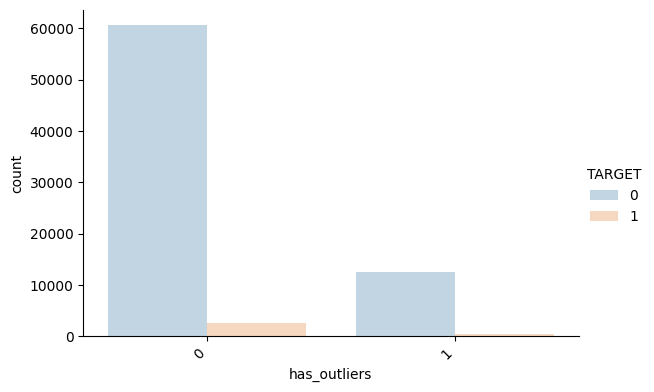

In [15]:
# has outliers vs target
display(
    pd.crosstab(
        df_train['has_outliers']
        , df_train['TARGET']
        , normalize='index').style.background_gradient(cmap='Set3').format("{:.2%}"
    )
)

g = sns.catplot(
    data=df_train,
    x="has_outliers",
    aspect=1.5,
    height=4,
    hue="TARGET",
    alpha=0.3,
    kind="count",
).set_xticklabels(rotation=45, horizontalalignment="right");

<div class="alert" style="background-color: #FFFFFF; border-left: 8px solid #1ABC9C; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

It is visually obvious that there's no relationship between target and 'has_outliers', so we can drop the feature

</div>

In [16]:
df_train.drop(columns=['has_outliers'], inplace=True)

In [17]:
# reordering columns
df_train = df_train[[col for col in df_train.columns if col not in ["TARGET"]] + ["TARGET"]]

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **Calculating Phik Correlation**: Phik Correlation + Visulization
</div>

In [18]:
df_train.columns

len(loaded_categorical_cols)

111

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

Since calculating phik correlation for whole dataset can be time and resurce consuming, we can calculate it by batches (with TARGET) with some limited number of features in each batch. It will be enough to check, if some features are correlated with target or not.
</div>

Calculating phik correlation for columns: ['Unnamed: 0', 'imp_op_var41_comer_ult3', 'num_var13_largo_0', 'num_var32', 'imp_op_var39_ult1', 'imp_aport_var17_ult1', 'ind_var37_cte', 'delta_num_aport_var17_1y3', 'num_var37_med_ult2', 'imp_reemb_var13_ult1', 'ind_var24', 'num_var43_recib_ult1', 'imp_trans_var37_ult1', 'num_var40', 'num_var45_ult3', 'delta_imp_amort_var34_1y3', 'TARGET']


<Figure size 1000x800 with 0 Axes>

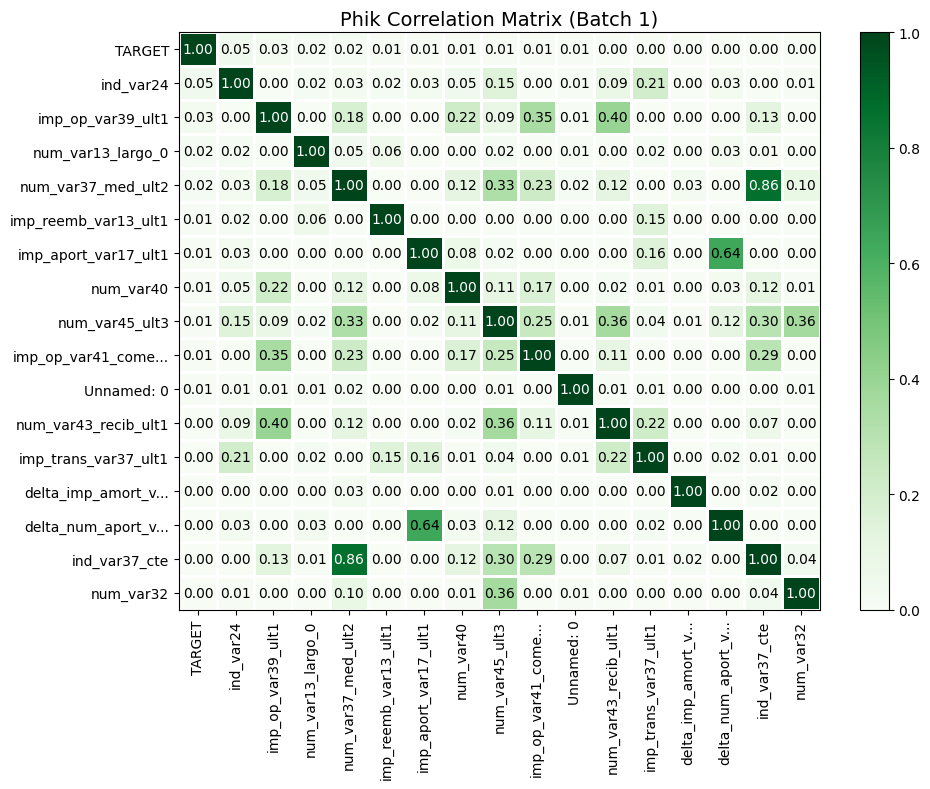

Calculating phik correlation for columns: ['imp_trasp_var33_in_ult1', 'imp_op_var40_ult1', 'num_trasp_var11_ult1', 'ind_var26_0', 'num_var20_0', 'saldo_var29', 'imp_aport_var17_hace3', 'ind_var24_0', 'num_var13_corto_0', 'saldo_medio_var13_corto_hace3', 'delta_imp_reemb_var17_1y3', 'imp_trasp_var33_out_ult1', 'var15', 'num_var31_0', 'ind_var12', 'ind_var13_0', 'TARGET']


<Figure size 1000x800 with 0 Axes>

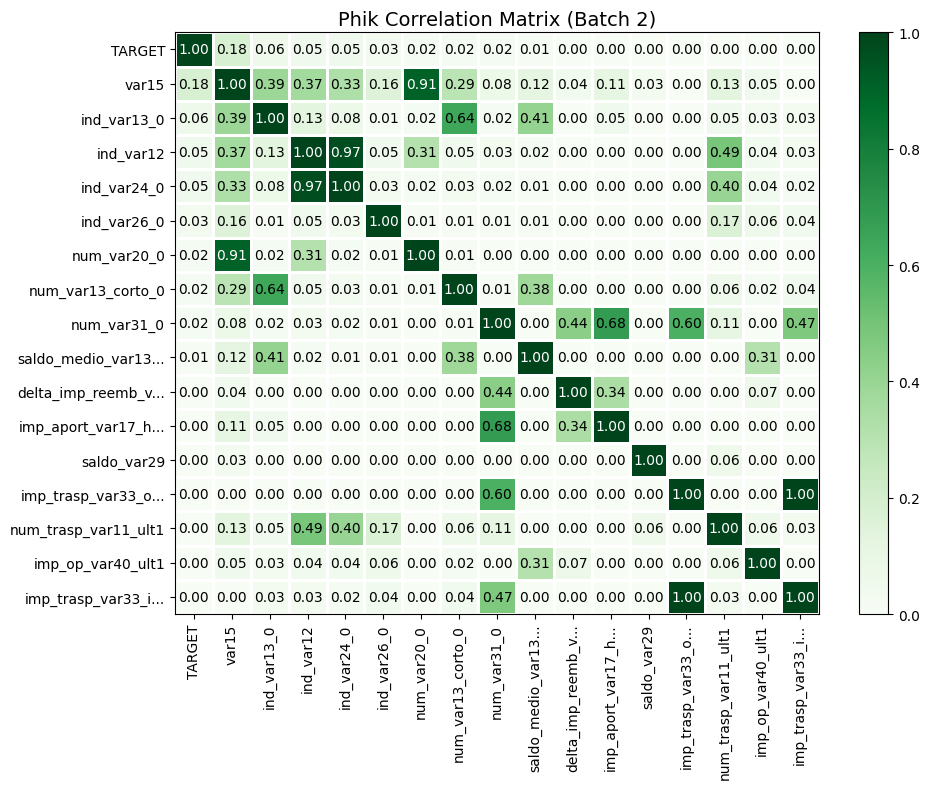

Calculating phik correlation for columns: ['saldo_medio_var12_hace3', 'num_op_var39_comer_ult3', 'num_var31', 'saldo_var18', 'imp_reemb_var33_ult1', 'num_op_var39_ult3', 'imp_aport_var13_hace3', 'saldo_medio_var13_largo_hace3', 'num_aport_var13_ult1', 'num_var7_recib_ult1', 'delta_imp_venta_var44_1y3', 'imp_var7_emit_ult1', 'num_op_var41_efect_ult1', 'num_var25_0', 'num_op_var40_efect_ult1', 'saldo_medio_var8_ult1', 'TARGET']


<Figure size 1000x800 with 0 Axes>

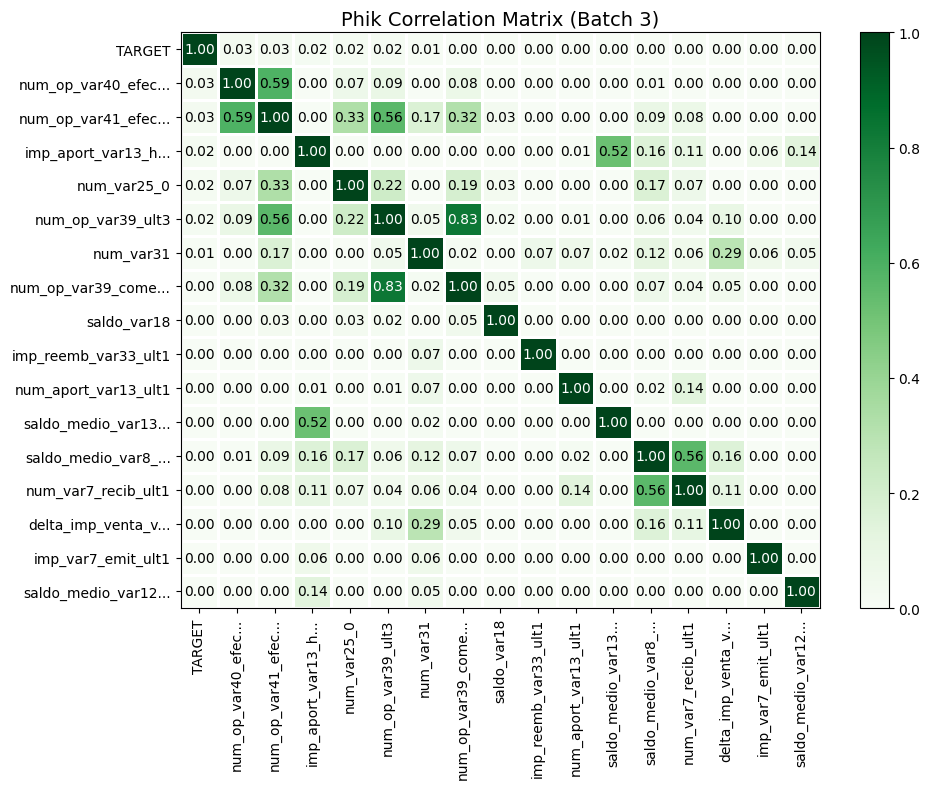

Calculating phik correlation for columns: ['imp_amort_var34_ult1', 'num_op_var41_comer_ult1', 'num_op_var39_hace2', 'delta_num_aport_var33_1y3', 'ind_var13_largo_0', 'saldo_medio_var13_medio_ult3', 'ind_var26_cte', 'num_var30_0', 'num_var41_0', 'delta_imp_compra_var44_1y3', 'saldo_medio_var44_ult3', 'num_op_var40_hace2', 'saldo_var8', 'saldo_medio_var13_largo_hace2', 'num_var45_hace2', 'imp_reemb_var17_ult1', 'TARGET']


<Figure size 1000x800 with 0 Axes>

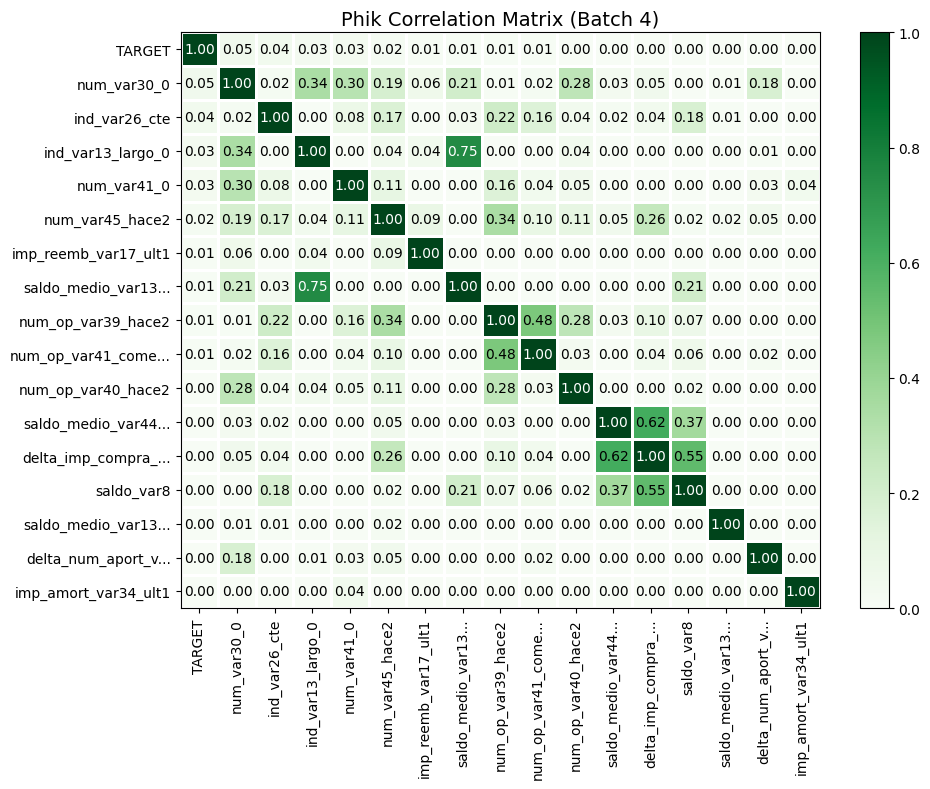

Calculating phik correlation for columns: ['saldo_var40', 'num_op_var39_ult1', 'ind_var41_0', 'num_op_var40_ult3', 'num_var22_ult3', 'imp_sal_var16_ult1', 'num_var35', 'imp_aport_var13_ult1', 'num_var17_0', 'saldo_medio_var33_hace2', 'num_var14', 'delta_imp_aport_var13_1y3', 'ind_var43_emit_ult1', 'num_var14_0', 'num_aport_var17_ult1', 'var21', 'TARGET']


<Figure size 1000x800 with 0 Axes>

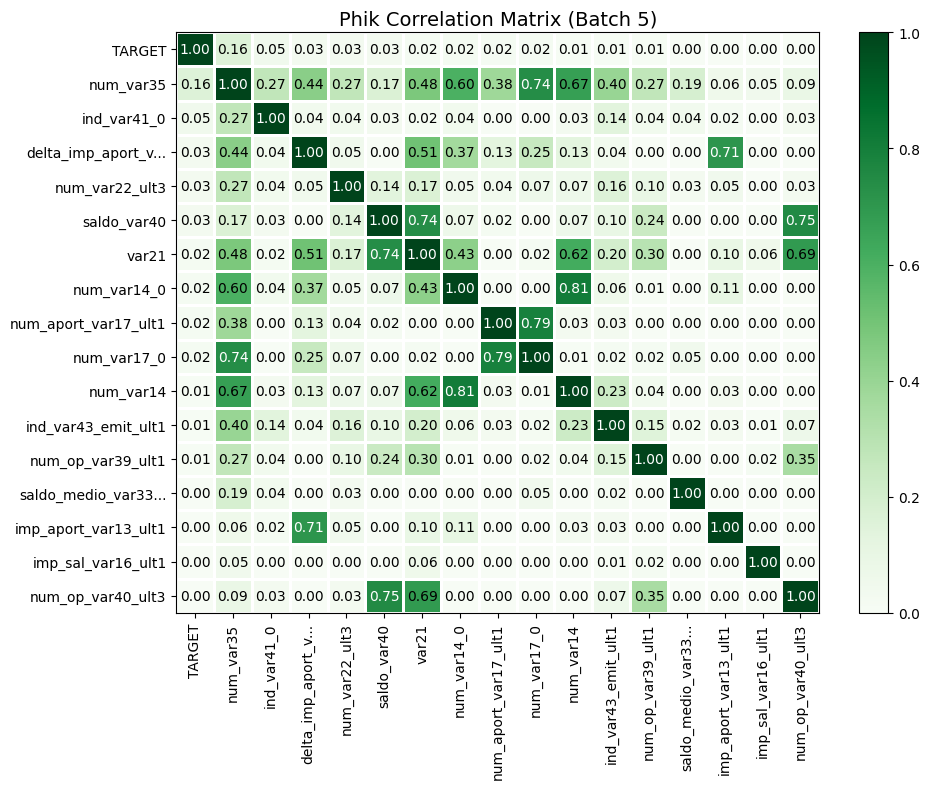

Calculating phik correlation for columns: ['num_var42', 'num_var5', 'ind_var37_0', 'saldo_var13_corto', 'saldo_var37', 'num_op_var40_comer_ult1', 'num_op_var41_hace3', 'delta_num_reemb_var13_1y3', 'imp_reemb_var17_hace3', 'delta_imp_amort_var18_1y3', 'num_var30', 'ind_var12_0', 'imp_op_var39_efect_ult1', 'num_var44', 'imp_var43_emit_ult1', 'num_meses_var13_largo_ult3', 'TARGET']


<Figure size 1000x800 with 0 Axes>

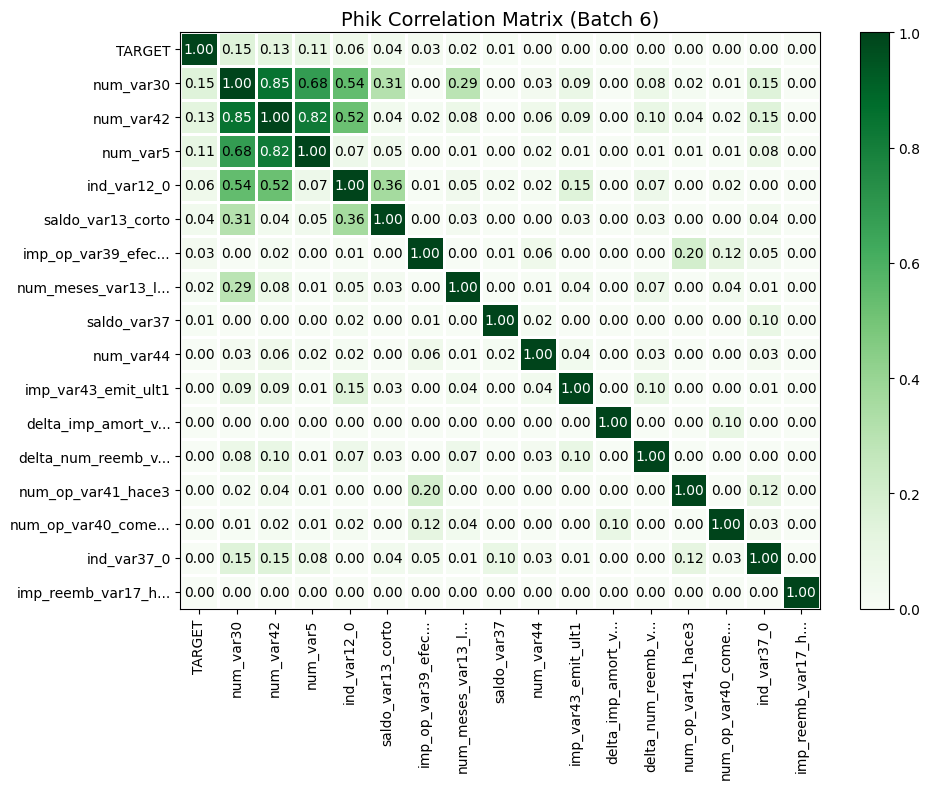

Calculating phik correlation for columns: ['delta_imp_trasp_var17_in_1y3', 'saldo_medio_var12_hace2', 'imp_compra_var44_hace3', 'num_venta_var44_ult1', 'saldo_medio_var29_hace2', 'saldo_var13_largo', 'ind_var43_recib_ult1', 'num_meses_var39_vig_ult3', 'saldo_medio_var5_ult1', 'num_var8_0', 'saldo_var26', 'num_var22_ult1', 'num_var17', 'imp_trasp_var17_in_hace3', 'saldo_var32', 'ind_var1_0', 'TARGET']


<Figure size 1000x800 with 0 Axes>

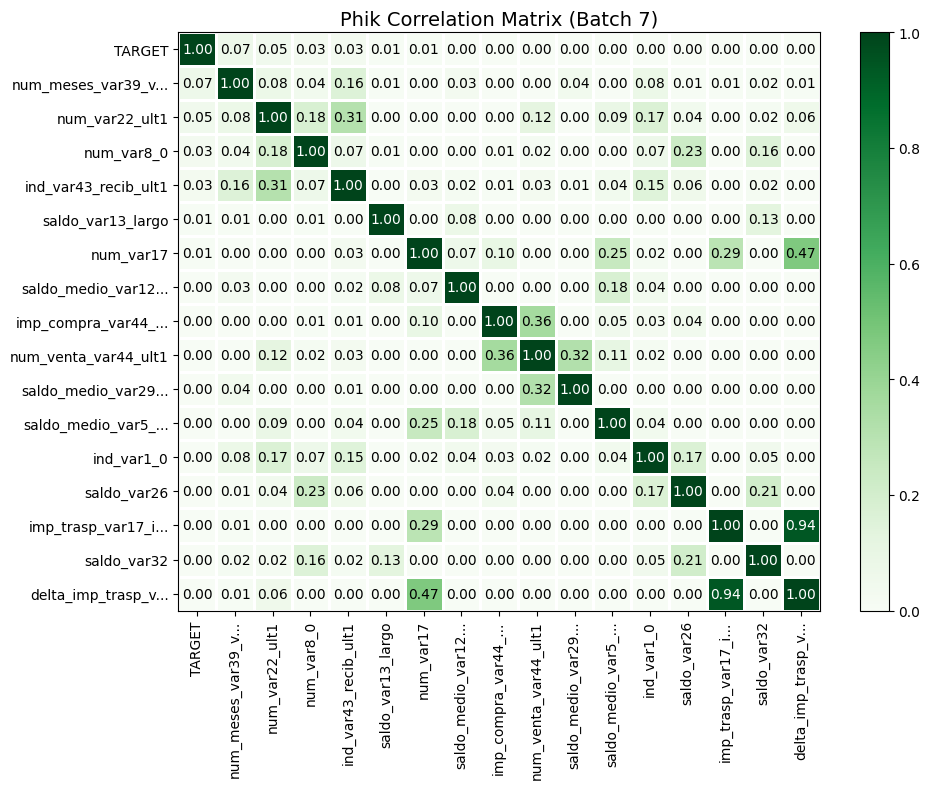

Calculating phik correlation for columns: ['num_meses_var5_ult3', 'var3', 'imp_op_var40_efect_ult3', 'saldo_medio_var29_hace3', 'saldo_var33', 'saldo_medio_var5_hace2', 'imp_op_var40_comer_ult3', 'imp_var7_recib_ult1', 'num_sal_var16_ult1', 'saldo_var42', 'imp_op_var40_comer_ult1', 'var36', 'saldo_medio_var13_largo_ult3', 'saldo_var5', 'delta_num_trasp_var33_in_1y3', 'ind_var5_0', 'TARGET']


<Figure size 1000x800 with 0 Axes>

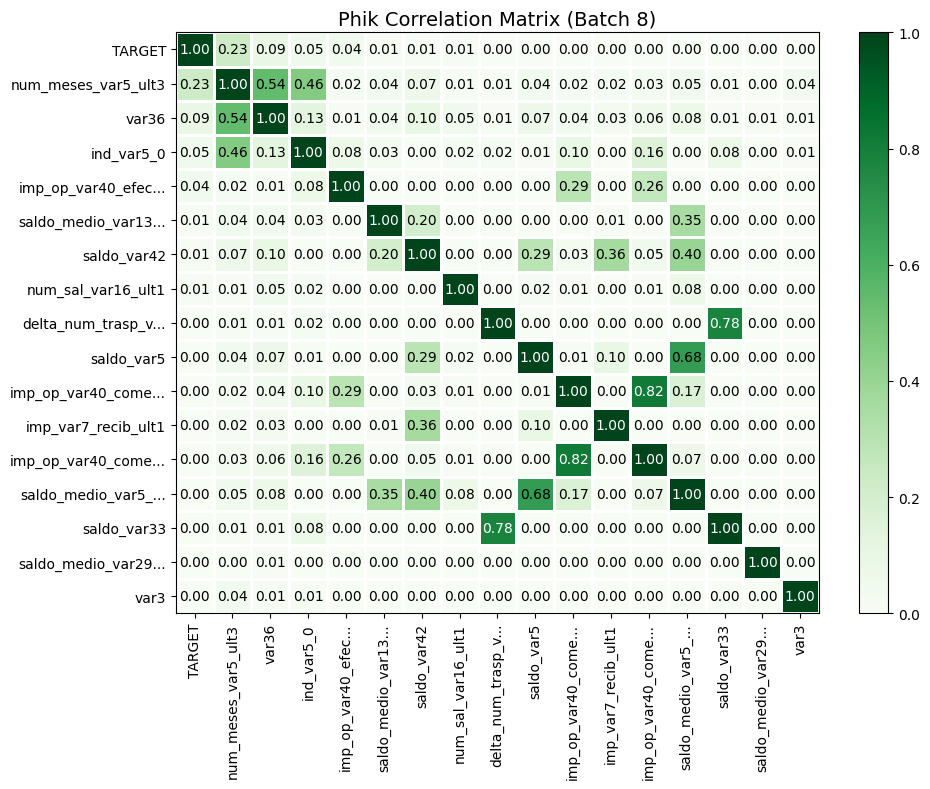

Calculating phik correlation for columns: ['num_var37_0', 'num_var45_hace3', 'saldo_var30', 'ind_var8', 'imp_venta_var44_hace3', 'num_aport_var17_hace3', 'num_op_var41_efect_ult3', 'num_var5_0', 'delta_imp_trasp_var17_out_1y3', 'num_var42_0', 'var38', 'num_op_var40_efect_ult3', 'saldo_medio_var13_corto_hace2', 'ind_var10_ult1', 'saldo_var14', 'num_var12_0', 'TARGET']


<Figure size 1000x800 with 0 Axes>

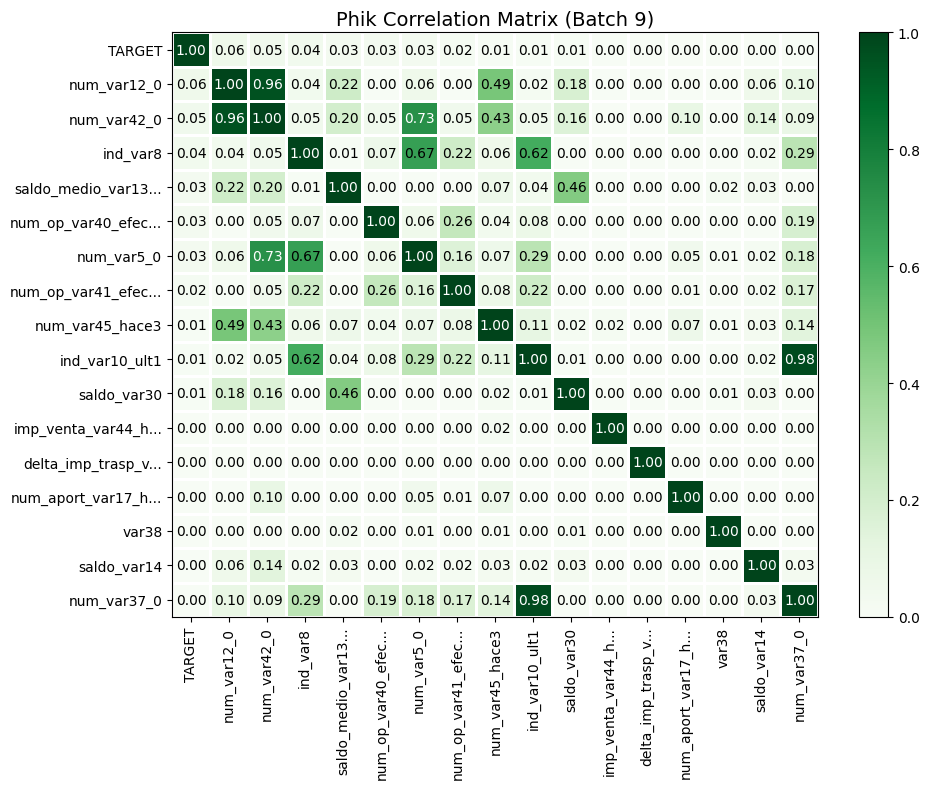

Calculating phik correlation for columns: ['num_var44_0', 'imp_aport_var33_ult1', 'imp_op_var39_efect_ult3', 'num_var22_hace3', 'imp_op_var39_comer_ult1', 'num_meses_var8_ult3', 'num_compra_var44_ult1', 'num_var22_hace2', 'num_var20', 'num_op_var40_hace3', 'saldo_medio_var29_ult3', 'saldo_medio_var33_hace3', 'imp_trasp_var17_out_ult1', 'ind_var9_cte_ult1', 'imp_ent_var16_ult1', 'num_aport_var13_hace3', 'TARGET']


<Figure size 1000x800 with 0 Axes>

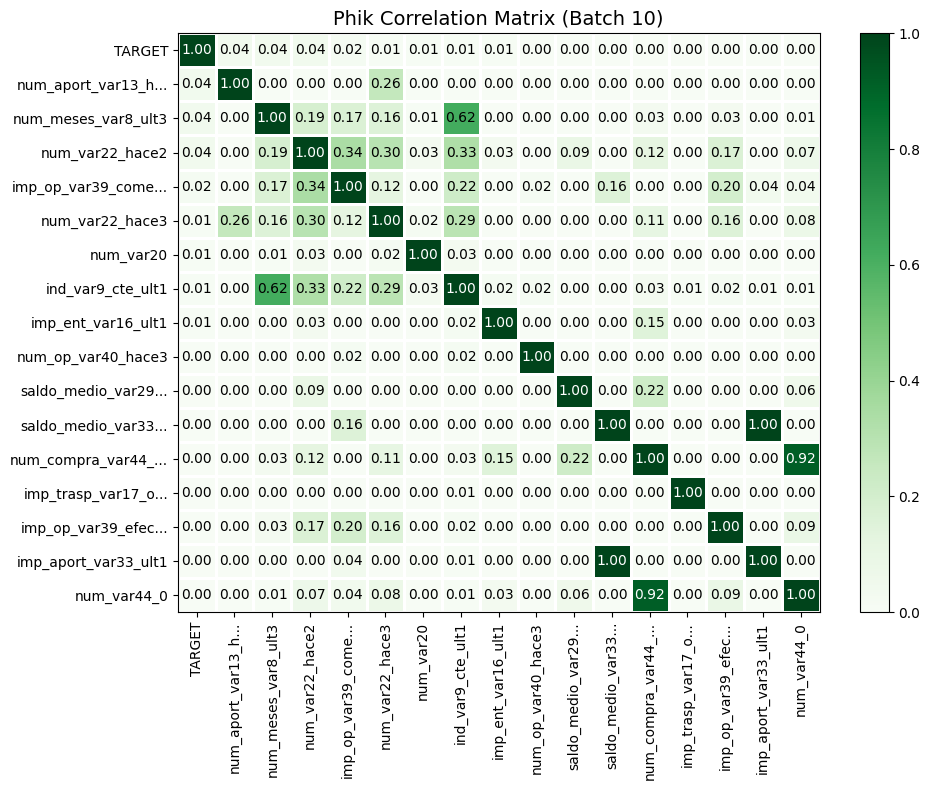

Calculating phik correlation for columns: ['ind_var14_0', 'imp_trasp_var33_in_hace3', 'num_ent_var16_ult1', 'saldo_medio_var5_ult3', 'num_var33_0', 'imp_trasp_var17_in_ult1', 'saldo_medio_var44_hace2', 'ind_var30', 'num_var45_ult1', 'num_var43_emit_ult1', 'saldo_medio_var8_hace2', 'imp_venta_var44_ult1', 'saldo_medio_var8_hace3', 'imp_op_var40_efect_ult1', 'saldo_var13', 'saldo_var20', 'TARGET']


<Figure size 1000x800 with 0 Axes>

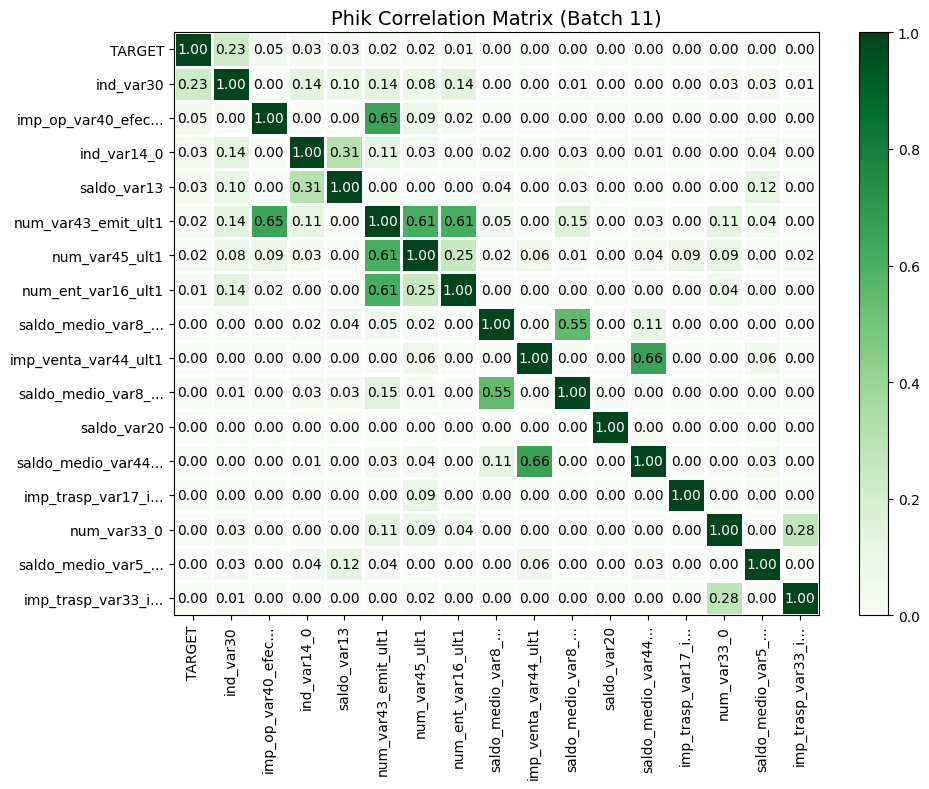

Calculating phik correlation for columns: ['saldo_medio_var5_hace3', 'saldo_medio_var44_hace3', 'saldo_medio_var8_ult3', 'saldo_var44', 'num_op_var40_comer_ult3', 'num_med_var22_ult3', 'imp_aport_var33_hace3', 'TARGET']


<Figure size 1000x800 with 0 Axes>

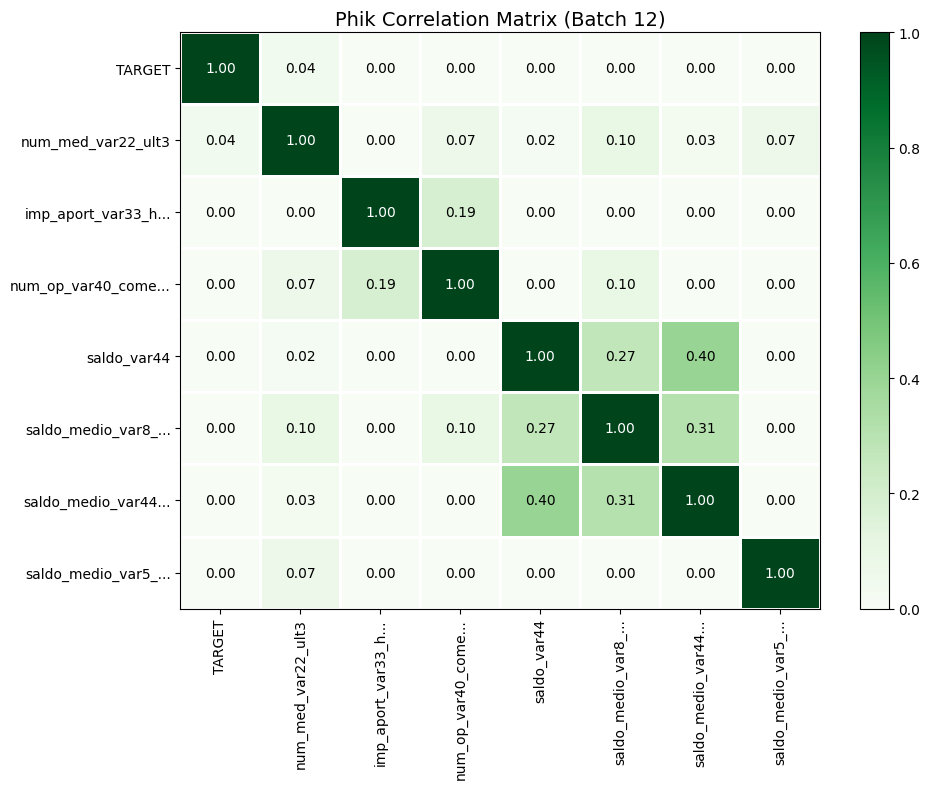

In [19]:
df_train['TARGET'] = df_train['TARGET'].astype('category')
# calculating phik correlation and visualising with 16 features per batch

# each batch sorted by TARGET and order in visuals is the same

for i in range(0, len(df_train.columns.to_list()), 16):
    batch_cols = df_train.columns.to_list()[i:i+16]
    if 'TARGET' not in batch_cols:
        batch_cols.append('TARGET')
    print(f"Calculating phik correlation for columns: {batch_cols}")
    
    phik_matrix_var = df_train[batch_cols].phik_matrix(interval_cols=interval_cols).round(2).sort_values('TARGET')
    phik_matrix_var = phik_matrix_var[phik_matrix_var.index.to_list()]

    plt.figure(figsize=(10, 8))
    plot_correlation_matrix(
        phik_matrix_var.values,
        x_labels=list(phik_matrix_var.columns),  # Mandatory
        y_labels=list(phik_matrix_var.index),    # Mandatory
        vmin=0,
        vmax=1,
        color_map="Greens",
        title=f'Phik Correlation Matrix (Batch {i//16 + 1})',
        figsize=(10, 8),                     # Optional: can match plt.figure size
        fontsize_factor=1                    # Adjust as needed
    )
    plt.tight_layout()
    plt.show()

# Revert target variable to int64
df_train['TARGET'] = df_train['TARGET'].astype('int64')

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

Let's remove some features that (constant features - if there are any, and highly imbalanced - can cause an error when calculating phik)
</div>

In [20]:
all_columns = [c for c in df_train.columns if c != 'TARGET' and df_train[c].nunique() > 1]

valid_cols = []
for col in all_columns:
    try:
        _ = df_train[[col, 'TARGET']].phik_matrix(interval_cols=[col])
        valid_cols.append(col)
    except Exception as e:
        print(f"Skipping {col} due to Phik error: {e}")
len(valid_cols)

183

In [21]:
imbalanced = [
    c for c in df_train.columns if c != 'TARGET' and df_train[c].nunique() > 1 
    if df_train[c].value_counts(normalize=True).iloc[0] > 0.995
]
print("Highly imbalanced sample:", imbalanced[:10])
print("Number of highly imbalanced columns:", len(imbalanced))
valid_cols = [c for c in valid_cols if c not in imbalanced]

Highly imbalanced sample: ['num_var32', 'imp_aport_var17_ult1', 'delta_num_aport_var17_1y3', 'imp_reemb_var13_ult1', 'num_var40', 'delta_imp_amort_var34_1y3', 'imp_trasp_var33_in_ult1', 'imp_op_var40_ult1', 'num_var20_0', 'saldo_var29']
Number of highly imbalanced columns: 78


In [22]:
df_train['TARGET'] = df_train['TARGET'].astype('category')
phik_matrix_var = df_train[valid_cols + ['TARGET']].phik_matrix(
        interval_cols=interval_cols,
        noise_correction=False,
        bins=10,         # fixed number of bins
        quantile=True,   # or False, but keep consistent
        njobs=1          # single process → reproducible
).round(2).sort_values('TARGET')
# phik_matrix = phik_matrix[phik_matrix.index.to_list()]

# Revert target variable to int64
df_train['TARGET'] = df_train['TARGET'].astype('int64')
phik_matrix_var

,Unnamed: 0,imp_op_var41_comer_ult3,num_var13_largo_0,imp_op_var39_ult1,ind_var37_cte,num_var37_med_ult2,ind_var24,num_var43_recib_ult1,imp_trans_var37_ult1,num_var45_ult3,num_trasp_var11_ult1,ind_var26_0,ind_var24_0,num_var13_corto_0,saldo_medio_var13_corto_hace3,var15,ind_var12,ind_var13_0,saldo_medio_var12_hace3,num_op_var39_comer_ult3,num_op_var39_ult3,imp_aport_var13_hace3,num_aport_var13_ult1,num_op_var41_efect_ult1,num_var25_0,saldo_medio_var8_ult1,num_op_var41_comer_ult1,num_op_var39_hace2,ind_var13_largo_0,ind_var26_cte,num_var30_0,num_var41_0,saldo_var8,saldo_medio_var13_largo_hace2,num_var45_hace2,num_op_var39_ult1,ind_var41_0,num_var22_ult3,num_var35,imp_aport_var13_ult1,num_var14,delta_imp_aport_var13_1y3,ind_var43_emit_ult1,num_var14_0,var21,num_var42,num_var5,ind_var37_0,saldo_var13_corto,saldo_var37,num_op_var41_hace3,num_var30,ind_var12_0,imp_op_var39_efect_ult1,imp_var43_emit_ult1,num_meses_var13_largo_ult3,saldo_medio_var12_hace2,saldo_var13_largo,ind_var43_recib_ult1,num_meses_var39_vig_ult3,saldo_medio_var5_ult1,num_var8_0,saldo_var26,num_var22_ult1,ind_var1_0,num_meses_var5_ult3,var3,saldo_medio_var5_hace2,saldo_var42,var36,saldo_medio_var13_largo_ult3,saldo_var5,ind_var5_0,num_var37_0,num_var45_hace3,saldo_var30,ind_var8,num_op_var41_efect_ult3,num_var5_0,num_var42_0,var38,saldo_medio_var13_corto_hace2,ind_var10_ult1,saldo_var14,num_var12_0,imp_op_var39_efect_ult3,num_var22_hace3,imp_op_var39_comer_ult1,num_meses_var8_ult3,num_var22_hace2,ind_var9_cte_ult1,imp_ent_var16_ult1,num_aport_var13_hace3,ind_var14_0,num_ent_var16_ult1,saldo_medio_var5_ult3,ind_var30,num_var45_ult1,num_var43_emit_ult1,saldo_medio_var8_hace2,saldo_medio_var8_hace3,saldo_var13,saldo_medio_var5_hace3,saldo_medio_var8_ult3,num_med_var22_ult3,TARGET
saldo_var37,0.01,0.23,0.01,0.23,1.00,0.87,0.00,0.20,0.20,0.49,0.16,0.35,0.00,0.02,0.03,0.24,0.02,0.04,0.00,0.23,0.23,0.04,0.01,0.32,0.23,0.33,0.22,0.20,0.01,0.36,0.03,0.13,0.33,0.01,0.27,0.23,0.15,0.21,0.69,0.01,0.08,0.03,0.37,0.02,0.14,0.15,0.08,1.00,0.04,1.00,0.12,0.15,0.00,0.42,0.37,0.01,0.02,0.01,0.48,0.15,0.32,0.12,0.35,0.18,0.17,0.21,0.11,0.30,0.48,0.31,0.01,0.30,0.25,1.00,0.20,0.34,0.33,0.18,0.13,0.04,0.03,0.04,0.99,0.08,0.02,0.18,0.23,0.22,0.32,0.27,0.95,0.31,0.03,0.01,0.22,0.42,0.24,0.52,0.29,0.27,0.18,0.04,0.29,0.33,0.23,0.00
imp_op_var39_comer_ult1,0.02,0.96,0.02,0.95,0.22,0.44,0.01,0.61,0.62,0.66,0.22,0.16,0.01,0.10,0.02,0.35,0.01,0.03,0.01,0.94,0.92,0.02,0.02,0.62,0.40,0.16,0.97,0.78,0.01,0.17,0.11,0.31,0.16,0.01,0.39,0.94,0.08,0.30,0.67,0.01,0.04,0.06,0.17,0.01,0.24,0.22,0.13,0.22,0.02,0.22,0.23,0.32,0.01,0.35,0.17,0.01,0.01,0.01,0.24,0.13,0.45,0.44,0.16,0.27,0.10,0.15,0.11,0.40,0.46,0.42,0.01,0.40,0.14,0.44,0.29,0.44,0.16,0.76,0.21,0.09,0.05,0.02,0.26,0.03,0.03,0.76,0.31,1.00,0.19,0.36,0.25,0.16,0.03,0.00,0.32,0.44,0.12,0.36,0.41,0.12,0.08,0.03,0.29,0.16,0.36,0.00
ind_var37_cte,0.01,0.23,0.01,0.23,1.00,0.86,0.00,0.20,0.20,0.51,0.16,0.35,0.00,0.02,0.04,0.25,0.02,0.04,0.00,0.23,0.24,0.04,0.01,0.32,0.23,0.33,0.22,0.21,0.01,0.36,0.03,0.14,0.33,0.01,0.29,0.23,0.16,0.22,0.71,0.01,0.08,0.03,0.38,0.01,0.14,0.16,0.08,1.00,0.04,1.00,0.13,0.16,0.00,0.42,0.38,0.01,0.02,0.01,0.49,0.16,0.32,0.12,0.35,0.18,0.17,0.22,0.11,0.31,0.49,0.31,0.01,0.31,0.25,1.00,0.22,0.34,0.33,0.18,0.13,0.04,0.03,0.04,0.97,0.08,0.02,0.19,0.24,0.22,0.32,0.27,0.97,0.31,0.03,0.01,0.22,0.43,0.25,0.53,0.29,0.27,0.18,0.04,0.32,0.33,0.24,0.00
ind_var1_0,0.01,0.07,0.04,0.09,0.17,0.16,0.15,0.06,0.07,0.24,0.19,0.20,0.15,0.03,0.06,0.12,0.17,0.10,0.11,0.09,0.09,0.06,0.03,0.14,0.13,0.20,0.07,0.08,0.05,0.21,0.30,0.05,0.20,0.04,0.13,0.09,0.02,0.14,0.29,0.03,0.12,0.08,0.24,0.05,1.00,0.12,0.03,0.17,0.08,0.17,0.06,0.13,0.16,0.17,0.24,0.05,0.16,0.05,0.15,0.08,0.11,0.07,0.20,0.18,1.00,0.07,0.25,0.13,0.24,0.11,0.05,0.10,0.29,0.18,0.11,0.15,0.20,0.07,0.15,0.35,0.02,0.09,0.29,0.12,0.15,0.08,0.17,0.10,0.22,0.19,0.49,0.05,0.06,0.10,0.03,0.18,0.04,0.23,0.22,0.19,0.17,0.10,0.15,0.20,0.21,0.00
ind_var37_0,0.01,0.23,0.01,0.23,1.00,0.87,0.00,

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

Save the results
</div>

In [23]:
with open("../src/reports/phik_matrix_var.pkl", "wb") as f:
    pickle.dump(phik_matrix_var, f)
with open("../src/reports/phik_matrix_var.pkl", "rb") as f:
    loaded_phik_matrix_var = pickle.load(f)
loaded_phik_matrix_var

,Unnamed: 0,imp_op_var41_comer_ult3,num_var13_largo_0,imp_op_var39_ult1,ind_var37_cte,num_var37_med_ult2,ind_var24,num_var43_recib_ult1,imp_trans_var37_ult1,num_var45_ult3,num_trasp_var11_ult1,ind_var26_0,ind_var24_0,num_var13_corto_0,saldo_medio_var13_corto_hace3,var15,ind_var12,ind_var13_0,saldo_medio_var12_hace3,num_op_var39_comer_ult3,num_op_var39_ult3,imp_aport_var13_hace3,num_aport_var13_ult1,num_op_var41_efect_ult1,num_var25_0,saldo_medio_var8_ult1,num_op_var41_comer_ult1,num_op_var39_hace2,ind_var13_largo_0,ind_var26_cte,num_var30_0,num_var41_0,saldo_var8,saldo_medio_var13_largo_hace2,num_var45_hace2,num_op_var39_ult1,ind_var41_0,num_var22_ult3,num_var35,imp_aport_var13_ult1,num_var14,delta_imp_aport_var13_1y3,ind_var43_emit_ult1,num_var14_0,var21,num_var42,num_var5,ind_var37_0,saldo_var13_corto,saldo_var37,num_op_var41_hace3,num_var30,ind_var12_0,imp_op_var39_efect_ult1,imp_var43_emit_ult1,num_meses_var13_largo_ult3,saldo_medio_var12_hace2,saldo_var13_largo,ind_var43_recib_ult1,num_meses_var39_vig_ult3,saldo_medio_var5_ult1,num_var8_0,saldo_var26,num_var22_ult1,ind_var1_0,num_meses_var5_ult3,var3,saldo_medio_var5_hace2,saldo_var42,var36,saldo_medio_var13_largo_ult3,saldo_var5,ind_var5_0,num_var37_0,num_var45_hace3,saldo_var30,ind_var8,num_op_var41_efect_ult3,num_var5_0,num_var42_0,var38,saldo_medio_var13_corto_hace2,ind_var10_ult1,saldo_var14,num_var12_0,imp_op_var39_efect_ult3,num_var22_hace3,imp_op_var39_comer_ult1,num_meses_var8_ult3,num_var22_hace2,ind_var9_cte_ult1,imp_ent_var16_ult1,num_aport_var13_hace3,ind_var14_0,num_ent_var16_ult1,saldo_medio_var5_ult3,ind_var30,num_var45_ult1,num_var43_emit_ult1,saldo_medio_var8_hace2,saldo_medio_var8_hace3,saldo_var13,saldo_medio_var5_hace3,saldo_medio_var8_ult3,num_med_var22_ult3,TARGET
saldo_var37,0.01,0.23,0.01,0.23,1.00,0.87,0.00,0.20,0.20,0.49,0.16,0.35,0.00,0.02,0.03,0.24,0.02,0.04,0.00,0.23,0.23,0.04,0.01,0.32,0.23,0.33,0.22,0.20,0.01,0.36,0.03,0.13,0.33,0.01,0.27,0.23,0.15,0.21,0.69,0.01,0.08,0.03,0.37,0.02,0.14,0.15,0.08,1.00,0.04,1.00,0.12,0.15,0.00,0.42,0.37,0.01,0.02,0.01,0.48,0.15,0.32,0.12,0.35,0.18,0.17,0.21,0.11,0.30,0.48,0.31,0.01,0.30,0.25,1.00,0.20,0.34,0.33,0.18,0.13,0.04,0.03,0.04,0.99,0.08,0.02,0.18,0.23,0.22,0.32,0.27,0.95,0.31,0.03,0.01,0.22,0.42,0.24,0.52,0.29,0.27,0.18,0.04,0.29,0.33,0.23,0.00
imp_op_var39_comer_ult1,0.02,0.96,0.02,0.95,0.22,0.44,0.01,0.61,0.62,0.66,0.22,0.16,0.01,0.10,0.02,0.35,0.01,0.03,0.01,0.94,0.92,0.02,0.02,0.62,0.40,0.16,0.97,0.78,0.01,0.17,0.11,0.31,0.16,0.01,0.39,0.94,0.08,0.30,0.67,0.01,0.04,0.06,0.17,0.01,0.24,0.22,0.13,0.22,0.02,0.22,0.23,0.32,0.01,0.35,0.17,0.01,0.01,0.01,0.24,0.13,0.45,0.44,0.16,0.27,0.10,0.15,0.11,0.40,0.46,0.42,0.01,0.40,0.14,0.44,0.29,0.44,0.16,0.76,0.21,0.09,0.05,0.02,0.26,0.03,0.03,0.76,0.31,1.00,0.19,0.36,0.25,0.16,0.03,0.00,0.32,0.44,0.12,0.36,0.41,0.12,0.08,0.03,0.29,0.16,0.36,0.00
ind_var37_cte,0.01,0.23,0.01,0.23,1.00,0.86,0.00,0.20,0.20,0.51,0.16,0.35,0.00,0.02,0.04,0.25,0.02,0.04,0.00,0.23,0.24,0.04,0.01,0.32,0.23,0.33,0.22,0.21,0.01,0.36,0.03,0.14,0.33,0.01,0.29,0.23,0.16,0.22,0.71,0.01,0.08,0.03,0.38,0.01,0.14,0.16,0.08,1.00,0.04,1.00,0.13,0.16,0.00,0.42,0.38,0.01,0.02,0.01,0.49,0.16,0.32,0.12,0.35,0.18,0.17,0.22,0.11,0.31,0.49,0.31,0.01,0.31,0.25,1.00,0.22,0.34,0.33,0.18,0.13,0.04,0.03,0.04,0.97,0.08,0.02,0.19,0.24,0.22,0.32,0.27,0.97,0.31,0.03,0.01,0.22,0.43,0.25,0.53,0.29,0.27,0.18,0.04,0.32,0.33,0.24,0.00
ind_var1_0,0.01,0.07,0.04,0.09,0.17,0.16,0.15,0.06,0.07,0.24,0.19,0.20,0.15,0.03,0.06,0.12,0.17,0.10,0.11,0.09,0.09,0.06,0.03,0.14,0.13,0.20,0.07,0.08,0.05,0.21,0.30,0.05,0.20,0.04,0.13,0.09,0.02,0.14,0.29,0.03,0.12,0.08,0.24,0.05,1.00,0.12,0.03,0.17,0.08,0.17,0.06,0.13,0.16,0.17,0.24,0.05,0.16,0.05,0.15,0.08,0.11,0.07,0.20,0.18,1.00,0.07,0.25,0.13,0.24,0.11,0.05,0.10,0.29,0.18,0.11,0.15,0.20,0.07,0.15,0.35,0.02,0.09,0.29,0.12,0.15,0.08,0.17,0.10,0.22,0.19,0.49,0.05,0.06,0.10,0.03,0.18,0.04,0.23,0.22,0.19,0.17,0.10,0.15,0.20,0.21,0.00
ind_var37_0,0.01,0.23,0.01,0.23,1.00,0.87,0.00,

In [24]:
df_train.shape

(76020, 184)

In [25]:
cols_phik_5p_Series = loaded_phik_matrix_var['TARGET'][loaded_phik_matrix_var['TARGET'] >= 0.05].sort_values(ascending=False)
cols_phik_all_Series = loaded_phik_matrix_var['TARGET'].sort_values(ascending=False)
cols_phik_all_Series
cols_phik_5p_Series

with open("../src/reports/cols_phik_all_Series.pkl", "wb") as f:
    pickle.dump(cols_phik_all_Series, f)
with open("../src/reports/cols_phik_all_Series.pkl", "rb") as f:
    loaded_cols_phik_all_Series = pickle.load(f)
display(loaded_cols_phik_all_Series)


with open("../src/reports/cols_phik_5p_Series.pkl", "wb") as f:
    pickle.dump(cols_phik_5p_Series, f)
with open("../src/reports/cols_phik_5p_Series.pkl", "rb") as f:
    loaded_cols_phik_5p_Series = pickle.load(f)
display(loaded_cols_phik_5p_Series)

TARGET                    1.00
ind_var30                 0.23
num_meses_var5_ult3       0.23
saldo_var42               0.20
saldo_medio_var5_ult3     0.19
                          ... 
ind_var1_0                0.00
ind_var37_cte             0.00
imp_op_var39_comer_ult1   0.00
ind_var37_0               0.00
saldo_var37               0.00
Name: TARGET, Length: 106, dtype: float64

TARGET                          1.00
ind_var30                       0.23
num_meses_var5_ult3             0.23
saldo_var42                     0.20
saldo_medio_var5_ult3           0.19
saldo_medio_var5_hace3          0.17
num_var35                       0.16
var15                           0.15
saldo_var30                     0.15
num_var30                       0.15
saldo_medio_var5_hace2          0.14
num_var42                       0.13
saldo_medio_var5_ult1           0.13
saldo_var5                      0.13
num_var5                        0.11
var36                           0.09
num_meses_var39_vig_ult3        0.07
ind_var13_0                     0.06
var38                           0.06
ind_var12_0                     0.06
saldo_var13                     0.06
num_var12_0                     0.06
ind_var5_0                      0.05
ind_var12                       0.05
saldo_medio_var12_hace2         0.05
ind_var24                       0.05
num_var30_0                     0.05
i

<Axes: >

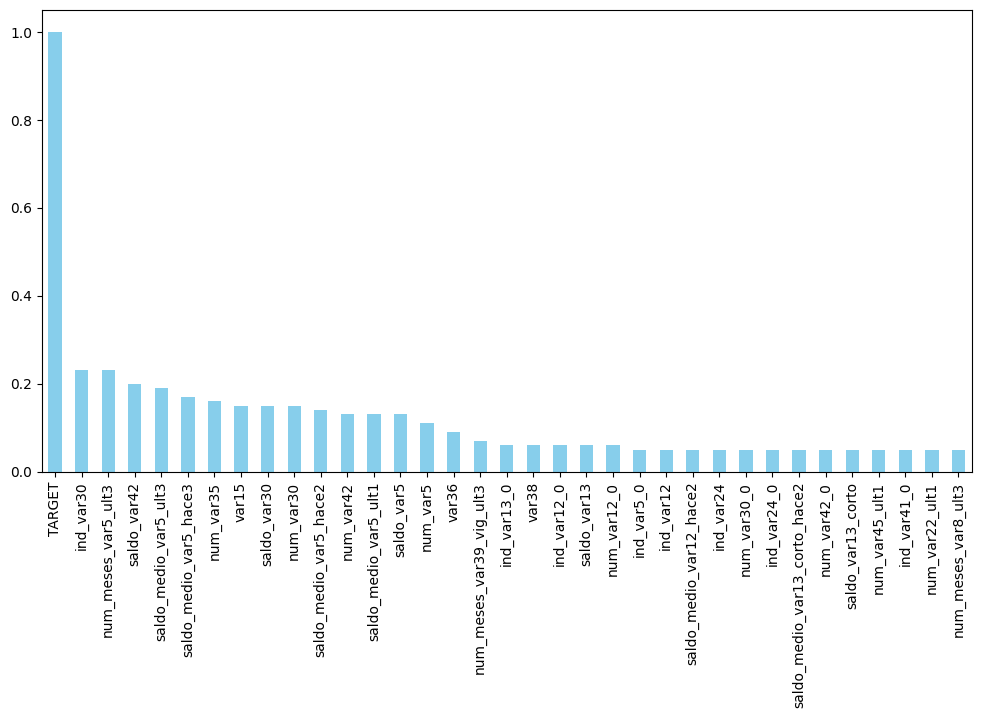

In [26]:
cols_phik_5p_Series = phik_matrix_var['TARGET'][phik_matrix_var['TARGET'] >= 0.05].sort_values(ascending=False)
cols_phik_5p_Series.plot(kind='bar', figsize=(12, 6), color='skyblue')

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **Visual Analysis**: Visualize features' distribution in different ways + target concentration
</div>

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

**Feature-wise class-normalized density distribution (Histogram-based)**
</div>

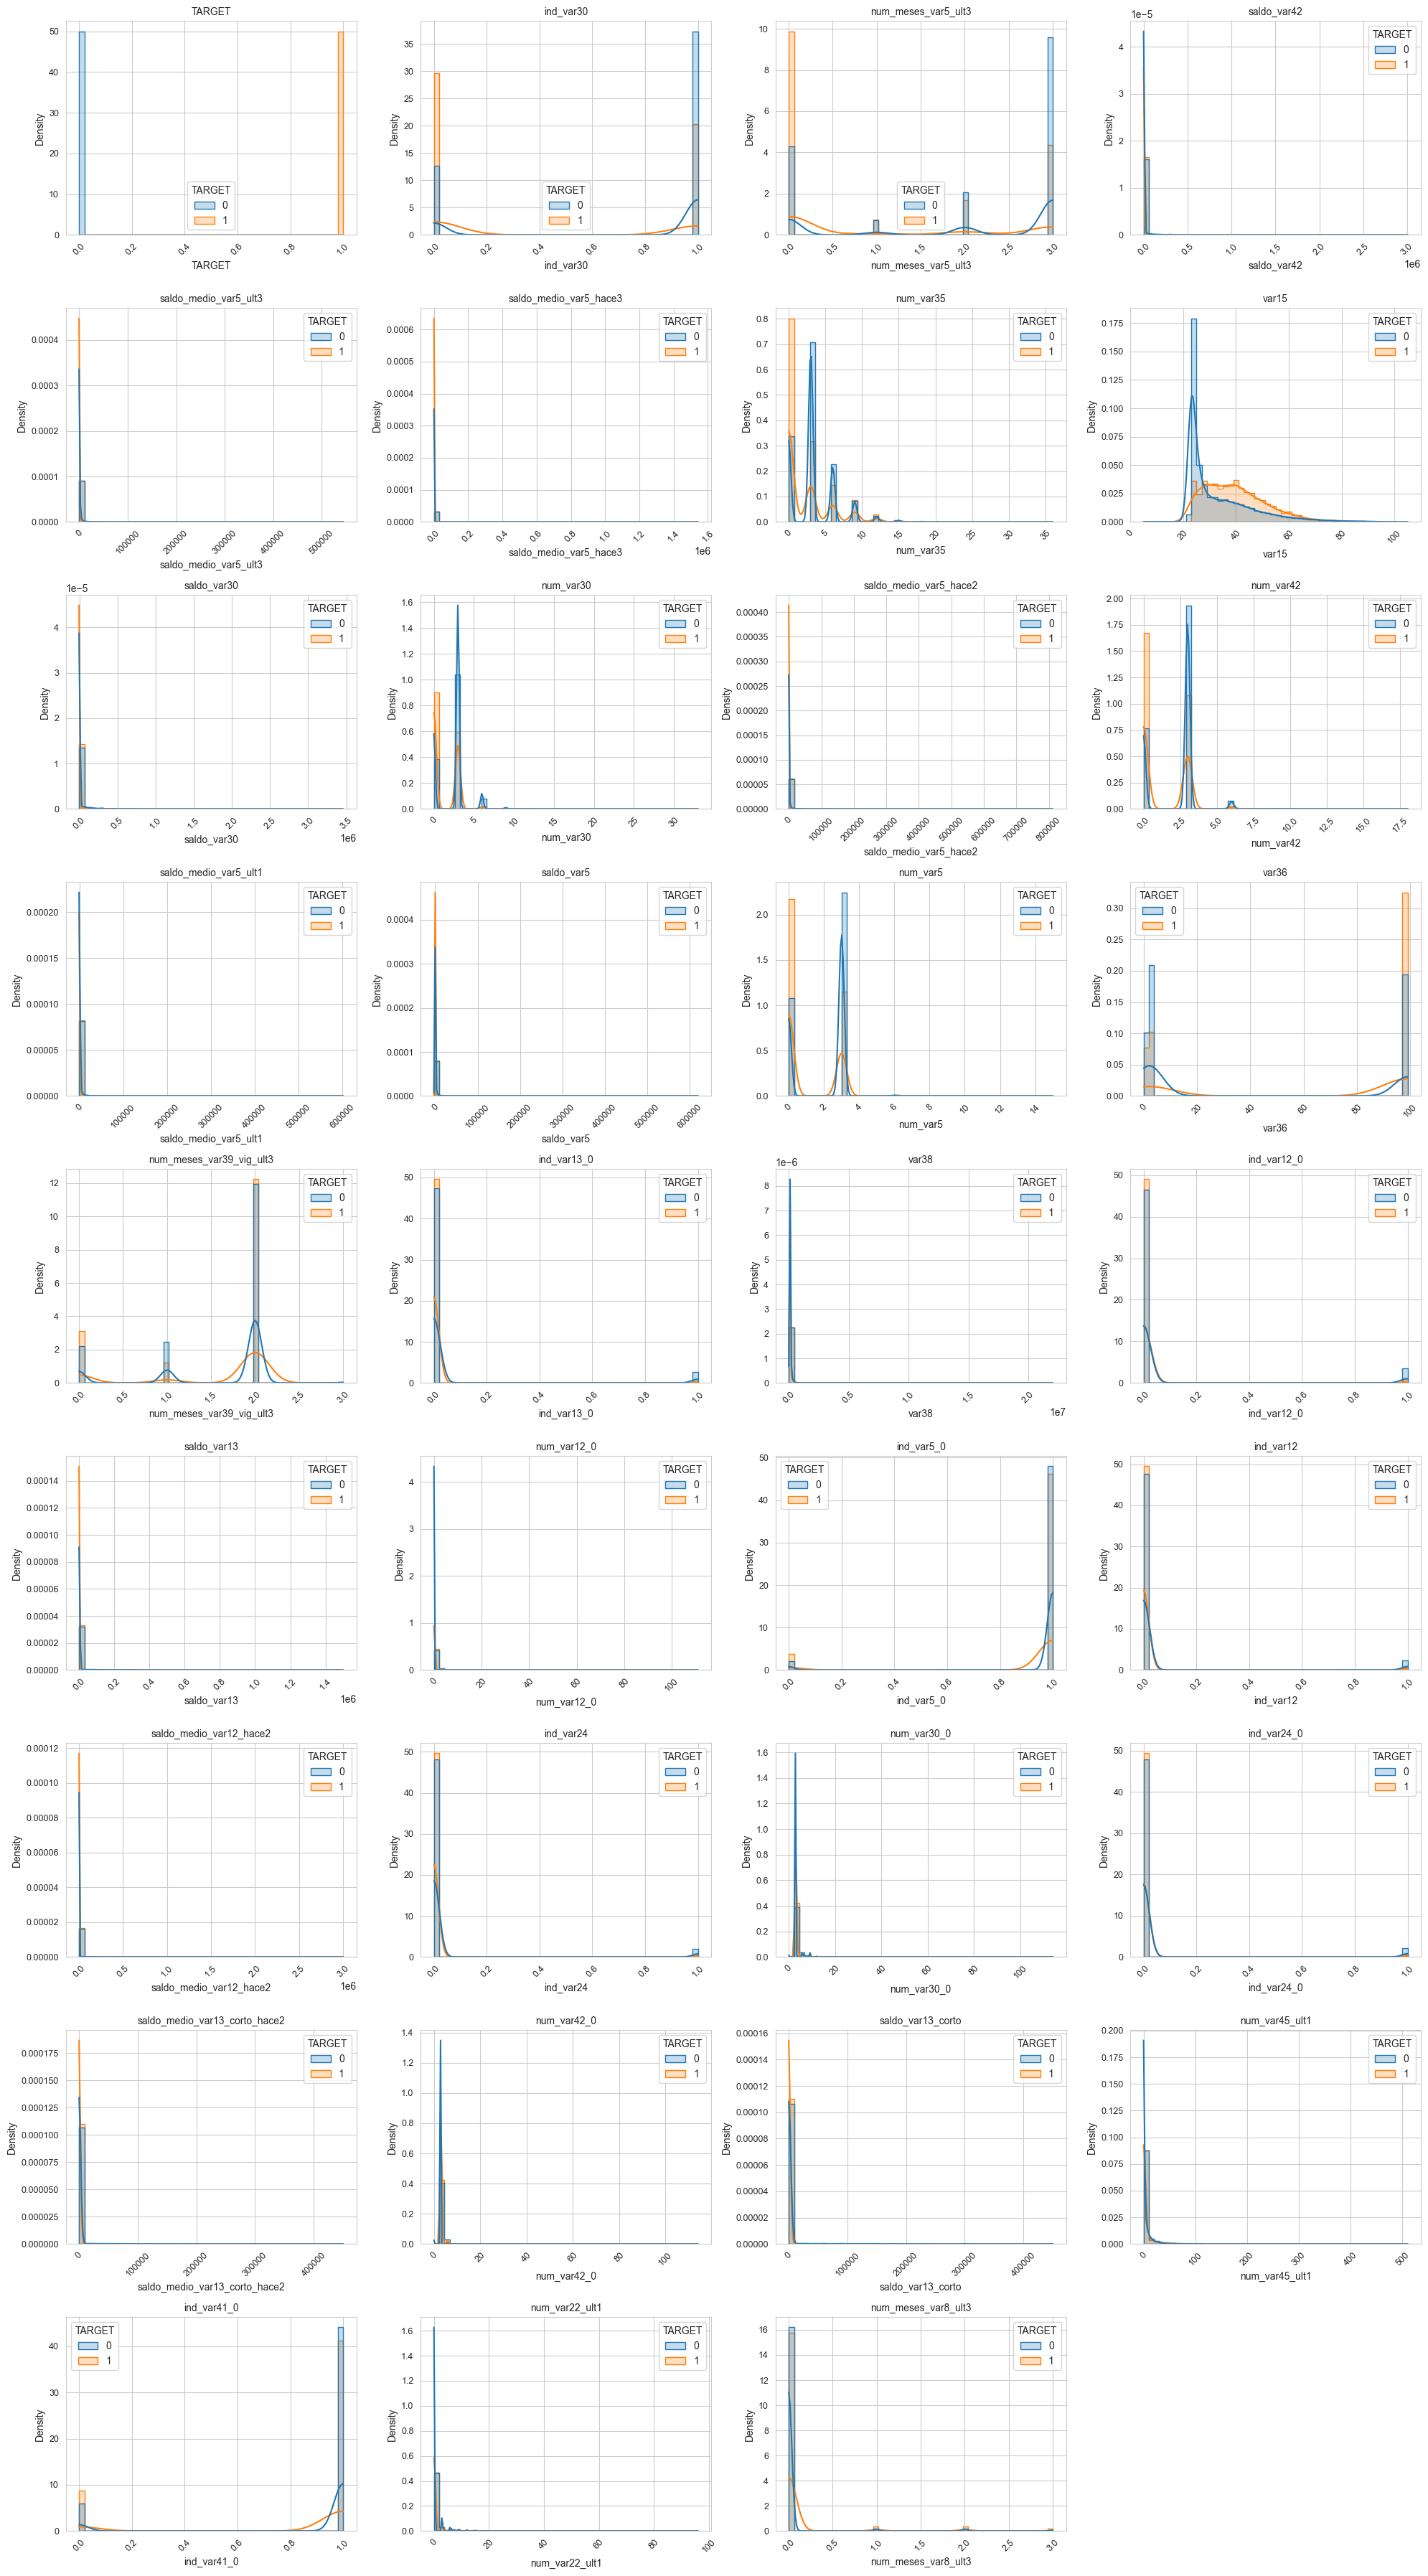

In [27]:
def plot_feature_histograms(df, target_col, features, n_cols=4):
    """
    Plots histograms with KDE overlays for a list of features, split by target column.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame containing the features and target column.
    target_col : str
        The name of the target column (e.g., 'TARGET').
    features : list
        List of feature column names to plot.
    n_cols : int, optional
        Number of columns in the subplot grid (default is 4).
    """
    sns.set_style('whitegrid')
    n_features = len(features)
    n_rows = math.ceil(n_features / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for i, feature in enumerate(features):
        ax = axes[i]
        sns.histplot(
            data=df,
            x=feature,
            hue=target_col,
            bins=50,
            kde=True,
            element="step",
            stat="density",
            common_norm=False,
            ax=ax
        )
        ax.set_title(feature, fontsize=10)
        ax.tick_params(axis='x', labelrotation=45)
        ax.tick_params(axis='x', which='major', labelsize=9)
        ax.tick_params(axis='y', which='major', labelsize=9)

    # Hide unused axes if features < grid size
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


# Example usage
cols = loaded_cols_phik_5p_Series.index.to_list()
# cols = [c for c in loaded_cols_phik_5p_Series.index.to_list()] + [c for c in df_train.columns.to_list() if c not in loaded_cols_phik_5p_Series.index.to_list()]
plot_feature_histograms(df_train, target_col="TARGET", features=cols, n_cols=4)


<div class="alert" style="background-color: #FFFFFF; border-left: 8px solid #1ABC9C; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

<div class="alert alert-info">

**First impressions** 
</div>

The correlation between the target and features can now be observed visually. Features like 
- `num_meses_var5_ult3`
- `ind_var30`
- `num_var30`
- `num_var4`
- `var15`

are obviously going to be in our predictive model.
</div>

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

Let's plot the graphs in a few more different ways.
</div>

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

**Feature-wise class-normalized density distribution (KDE-based)**
</div>

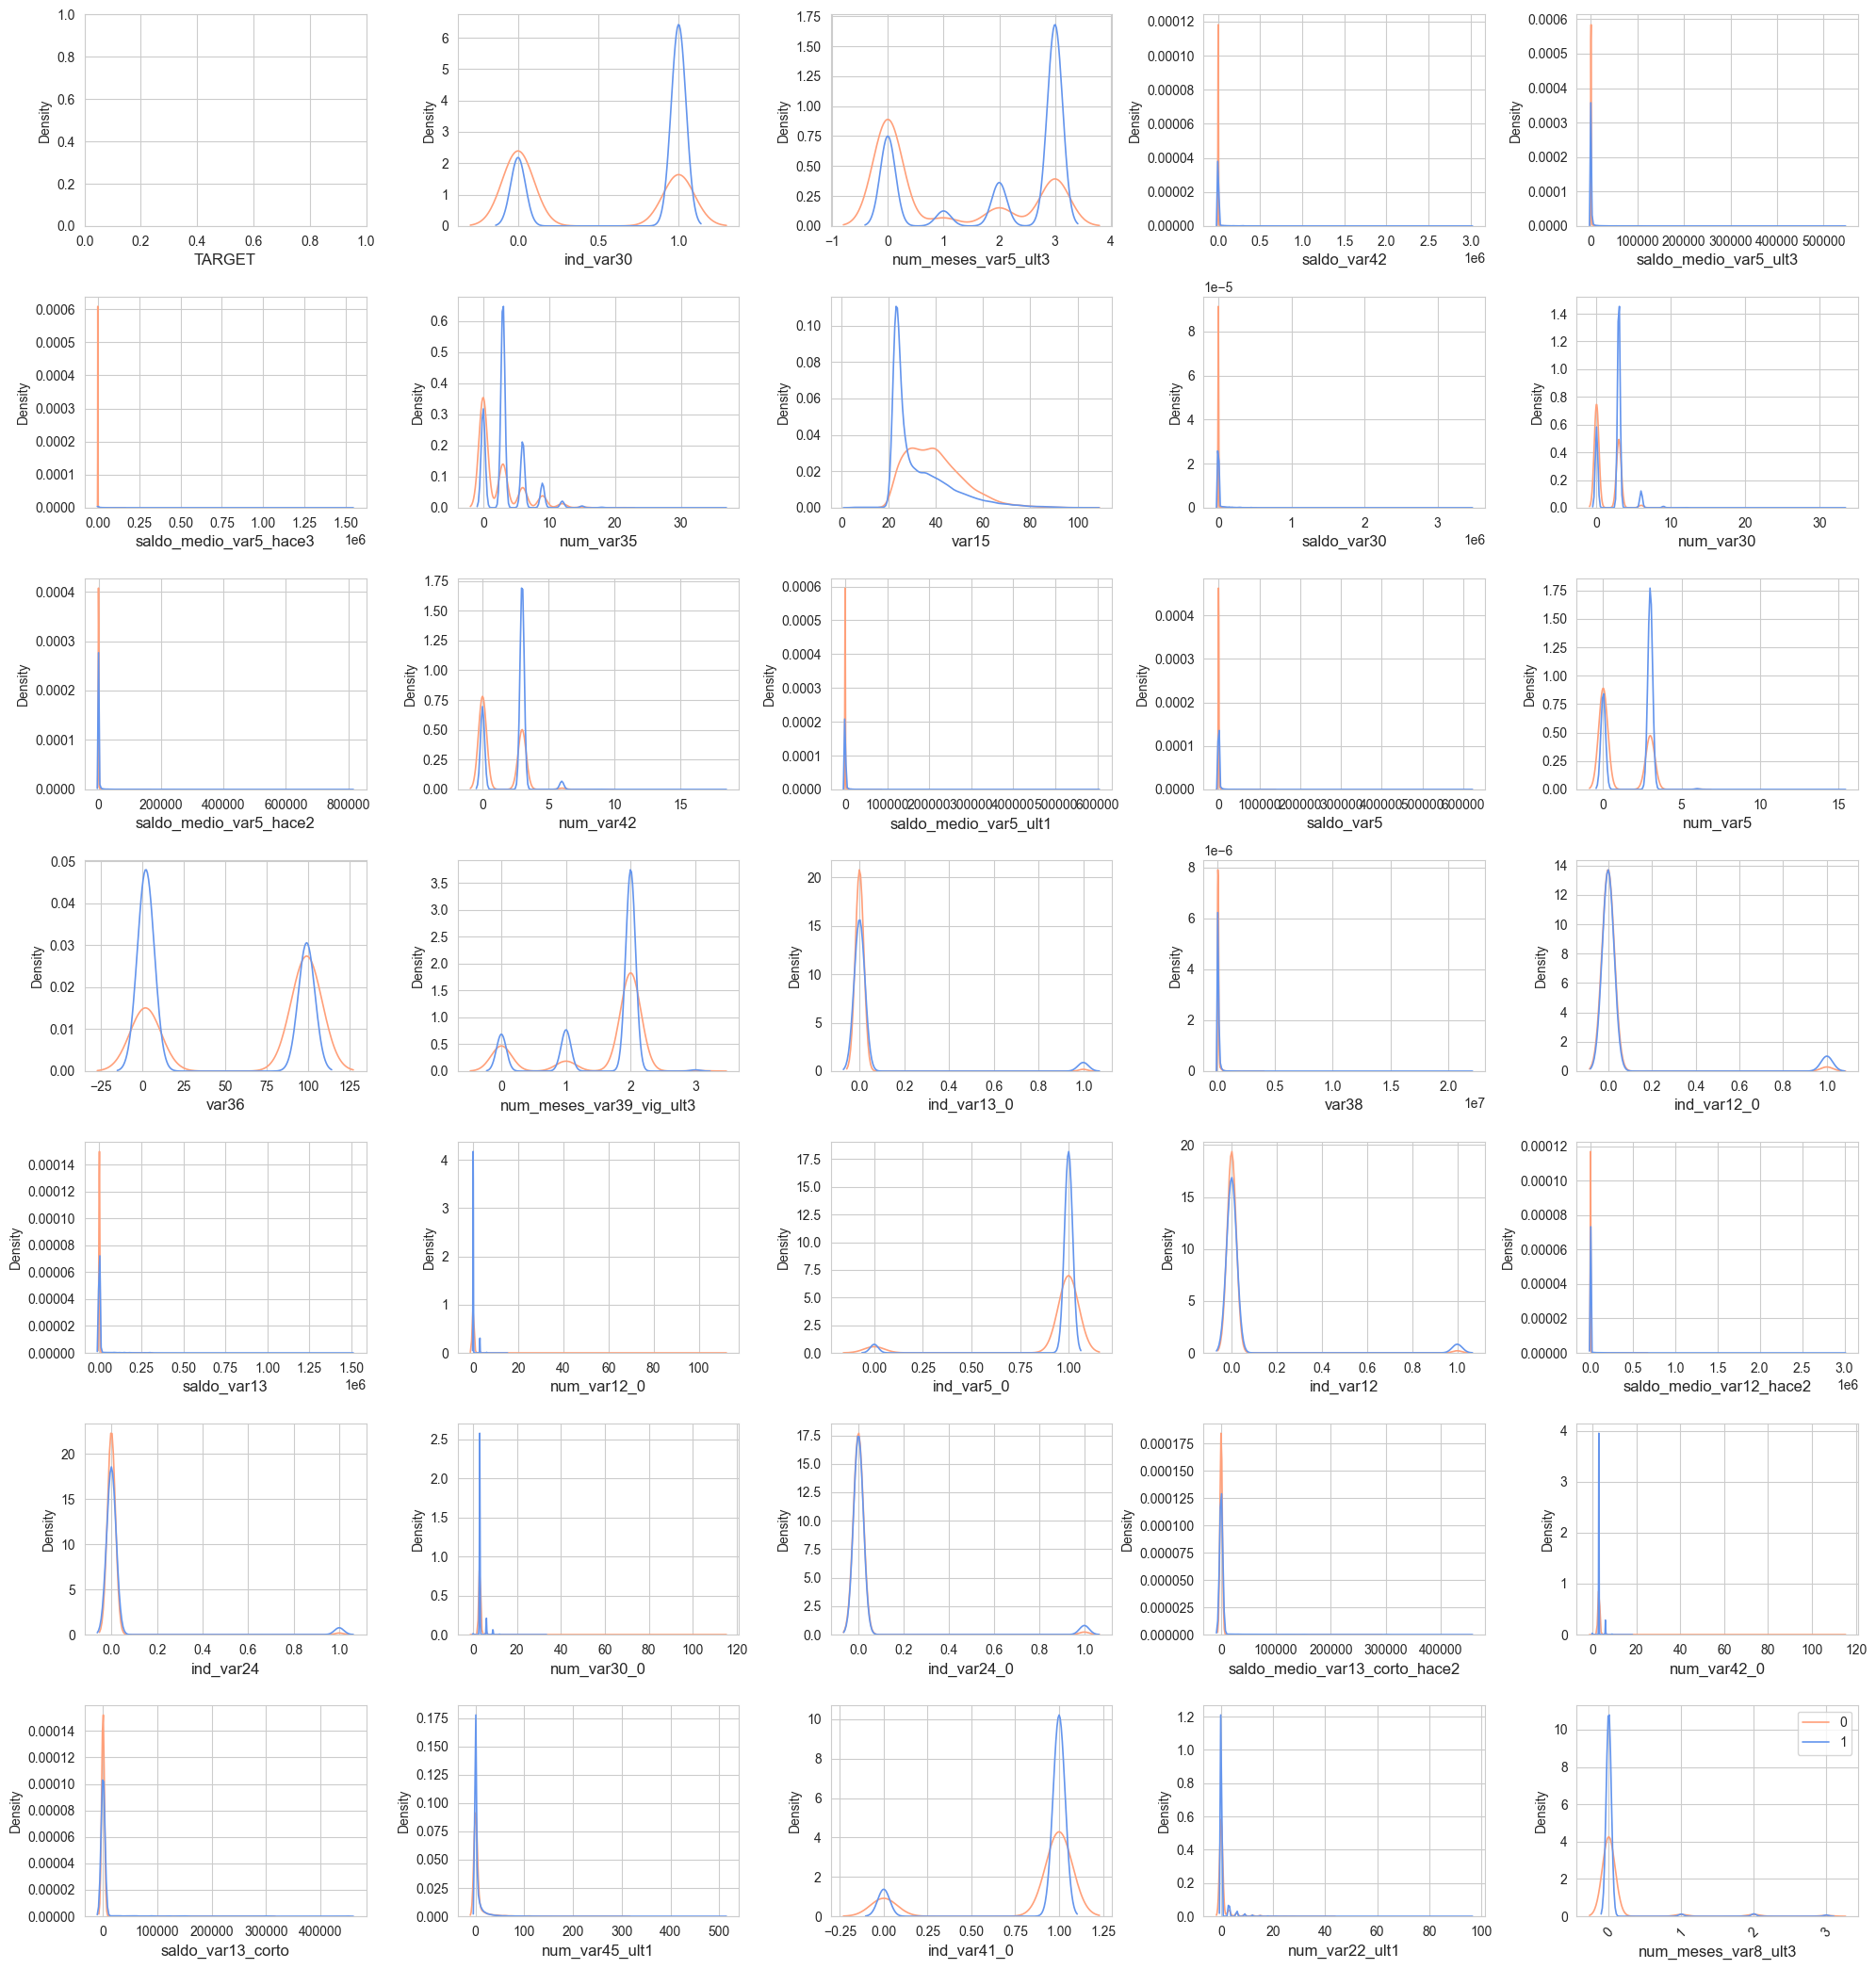

In [28]:
def plot_feature_distribution(df_target_1, df_target_0, label1, label2, features):
    sns.set_style('whitegrid')

    n_features = len(features)
    n_cols = 5   # you can adjust this
    n_rows = math.ceil(n_features / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
    axes = axes.flatten()  # make it 1D for easy indexing

    for i, feature in enumerate(features):
        ax = axes[i]
        sns.kdeplot(df_target_0[feature], label=label1, fill=False, linewidth=1.2, ax=ax, color='lightsalmon')
        sns.kdeplot(df_target_1[feature], label=label2, fill=False, linewidth=1.2, ax=ax, color='cornflowerblue')
        ax.set_xlabel(feature, fontsize=12)
        ax.tick_params(axis='x', which='major', labelsize=10)
        ax.tick_params(axis='y', which='major', labelsize=10)

    # Hide any unused subplots
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.xticks(rotation=45) # rotating x-axis labels for better readability
    plt.tight_layout()
    plt.legend()
    plt.show();


t0 = df_train.loc[df_train['TARGET'] == 0]
t1 = df_train.loc[df_train['TARGET'] == 1]
# features = df_train.columns.values[:-2]# df_train.columns.values[2:102]
# features = [c for c in loaded_cols_phik_5p_Series.index.to_list()] + [c for c in df_train.columns.to_list() if c not in loaded_cols_phik_5p_Series.index.to_list()]
features = loaded_cols_phik_5p_Series.index.to_list()
plot_feature_distribution(t0, t1, 0, 1, features)

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

**Feature-wise class-normalized distribution analysis (equal-width-binning-based)**
</div>

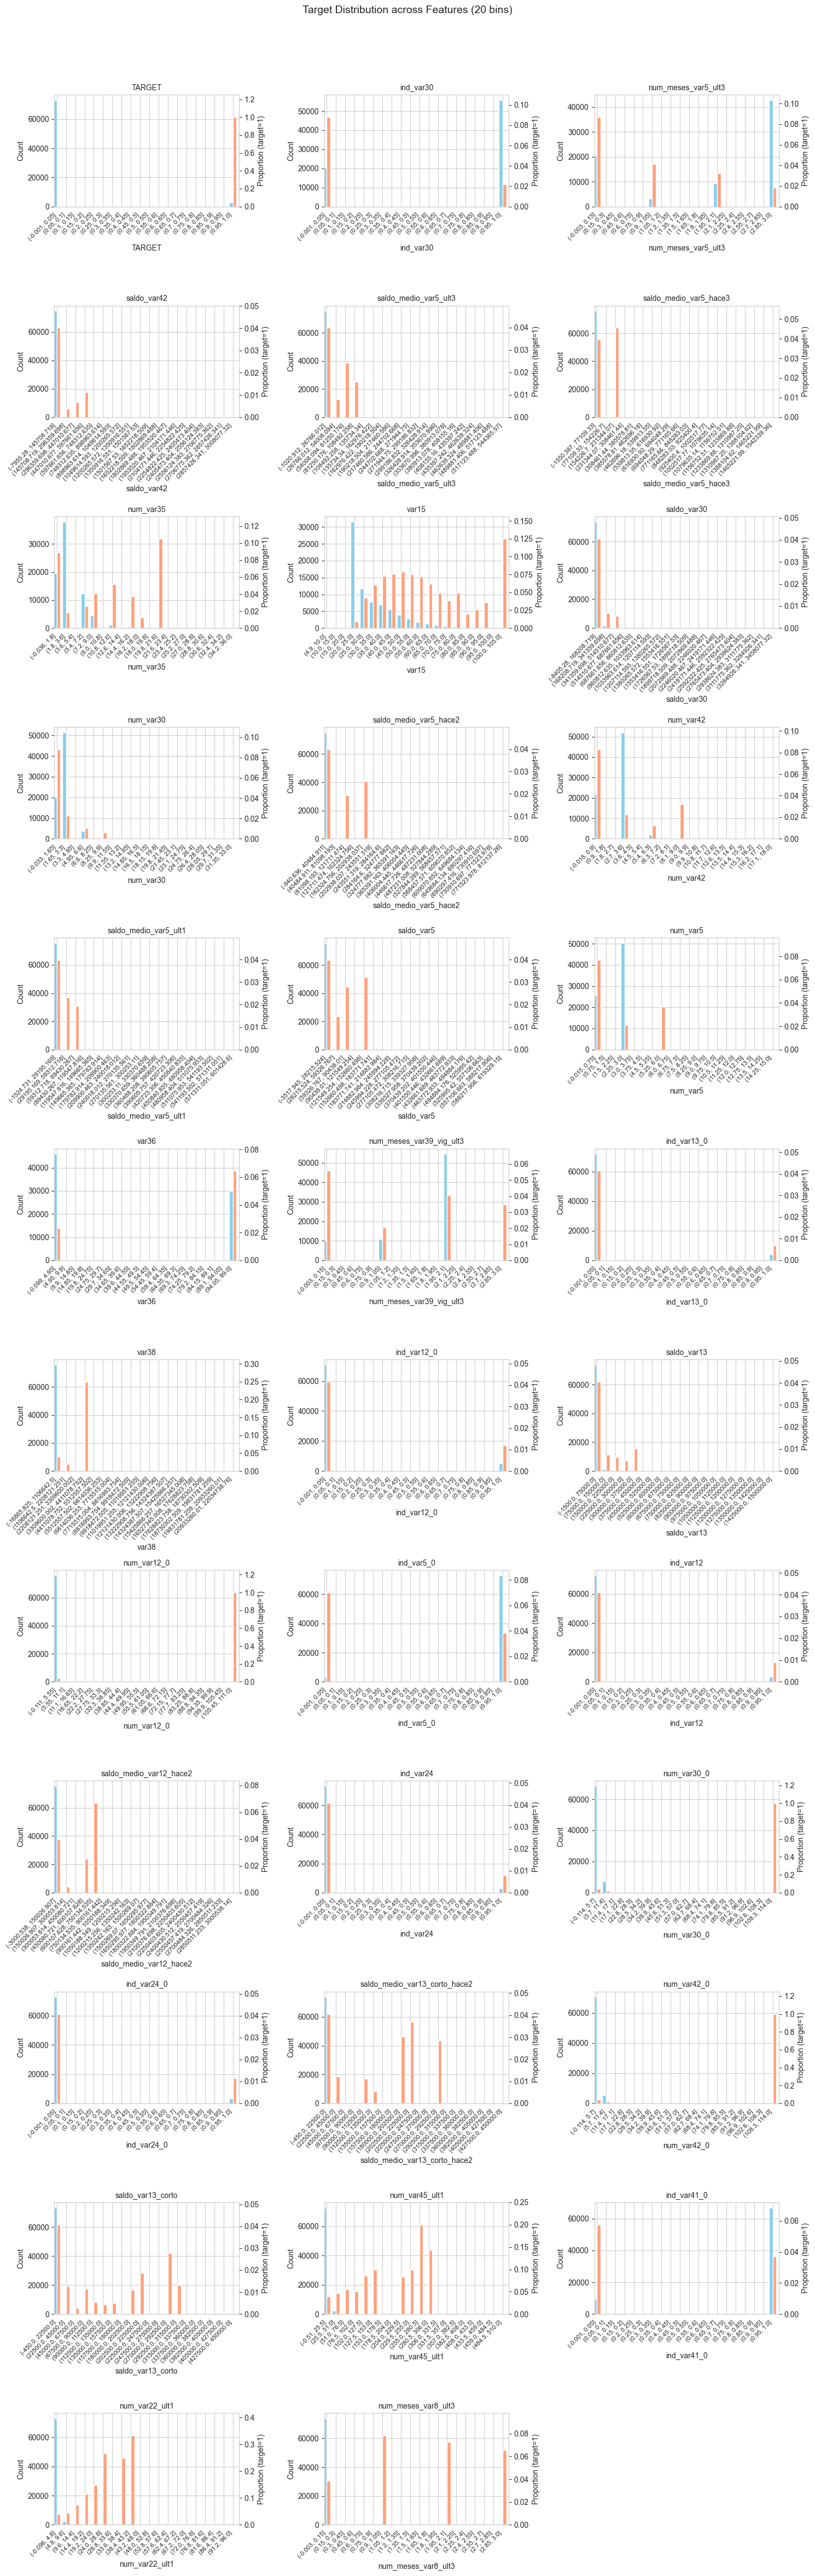

In [29]:
def plot_target_distribution_grid(data, features, target_feature, bins=10, quantile=False, ncols=3):
    n_features = len(features)
    nrows = int(np.ceil(n_features / ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 5, nrows * 4))
    axes = axes.flatten()  # flatten to simplify indexing

    for idx, feature in enumerate(features):
        ax = axes[idx]
        temp = data.copy()

        # Create bins (equal-width or equal-frequency)
        if quantile:
            temp['interval_bins'] = pd.qcut(temp[feature], q=bins, duplicates='drop')
        else:
            temp['interval_bins'] = pd.cut(temp[feature], bins=bins)

        # Calculate stats
        counts = temp['interval_bins'].value_counts().sort_index()
        proportions = temp[temp[target_feature] == 1].groupby('interval_bins').size() / counts
        plot_data = pd.DataFrame({'Counts': counts, 'Proportion': proportions}).fillna(0)

        # Plot counts
        plot_data['Counts'].plot(kind='bar', color='skyblue', ax=ax, position=1, width=0.4)
        ax.set_ylabel('Count')
        ax.set_xlabel(feature)
        ax.set_title(feature, fontsize=10)
        ax.set_xticklabels(plot_data.index.astype(str), rotation=45, ha='right', fontsize=8)

        # Second y-axis for proportion
        ax2 = ax.twinx()
        plot_data['Proportion'].plot(kind='bar', color='lightsalmon', ax=ax2, position=0, width=0.4)
        ax2.set_ylim(0, plot_data['Proportion'].max() * 1.25)
        ax2.set_ylabel('Proportion (target=1)')

        temp.drop(columns=['interval_bins'], inplace=True, errors='ignore')
        # gridlines for clarity
        ax.grid(True)
        ax2.grid(False)

    # Remove empty subplots
    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f'Target Distribution across Features ({bins} bins)', fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
plot_target_distribution_grid(df_train, loaded_cols_phik_5p_Series.index.to_list(), 'TARGET', bins=20)


<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

**Feature-wise class-normalized distribution analysis (quantile-binning-based)**
</div>

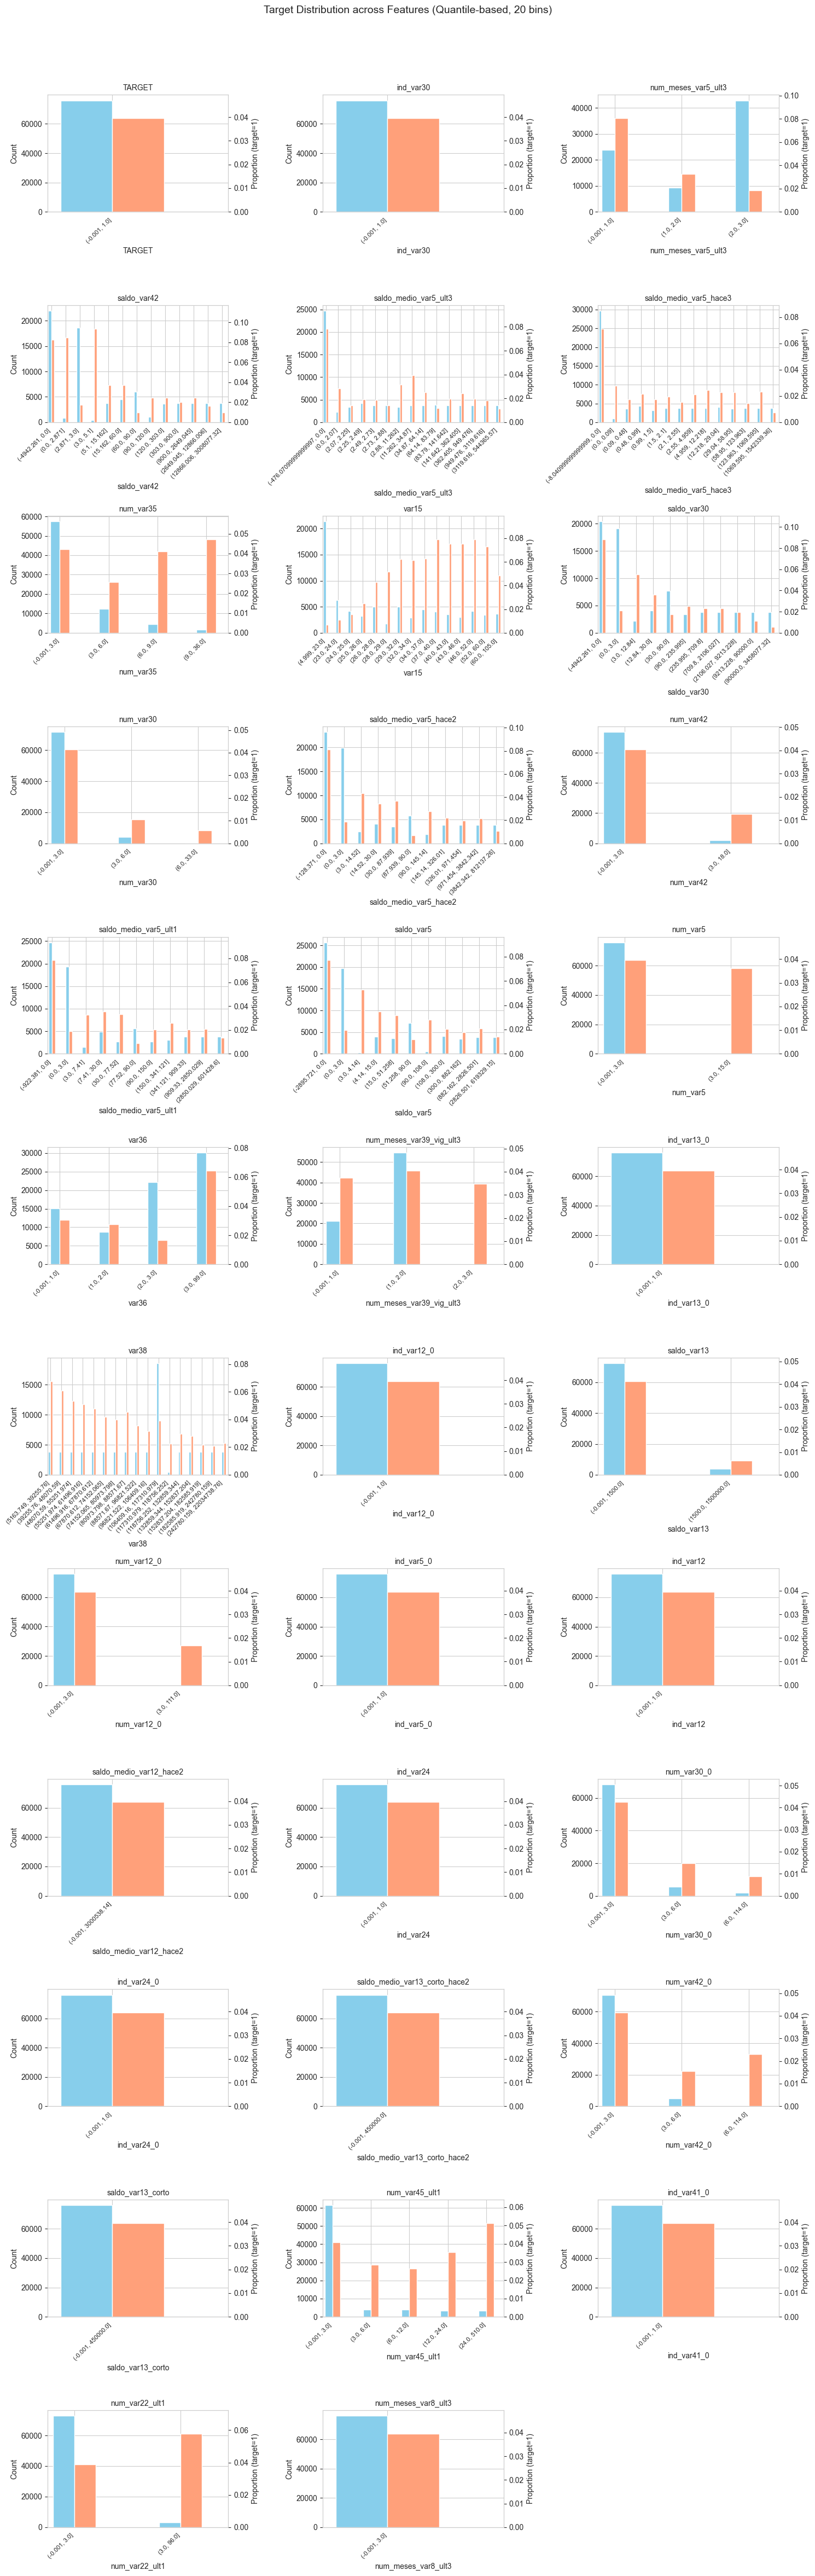

In [30]:
def plot_target_distribution_equal_grid(data, features, target_feature, bins=10, ncols=3):
    n_features = len(features)
    nrows = int(np.ceil(n_features / ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 5, nrows * 4))
    axes = axes.flatten()

    for idx, feature in enumerate(features):
        ax = axes[idx]
        temp = data.copy()

        # Quantile-based bins
        temp['interval_bins'] = pd.qcut(temp[feature], q=bins, duplicates='drop')

        # Counts and target proportions
        counts = temp['interval_bins'].value_counts().sort_index()
        proportions = temp[temp[target_feature] == 1].groupby('interval_bins').size() / counts
        plot_data = pd.DataFrame({'Counts': counts, 'Proportion': proportions}).fillna(0)

        # Plot counts
        plot_data['Counts'].plot(kind='bar', color='skyblue', ax=ax, position=1, width=0.2)
        ax.set_ylabel('Count')
        ax.set_xlabel(feature)
        ax.set_title(feature, fontsize=10)
        ax.set_xticklabels(plot_data.index.astype(str), rotation=45, ha='right', fontsize=8)

        # Second y-axis for proportion
        ax2 = ax.twinx()
        plot_data['Proportion'].plot(kind='bar', color='lightsalmon', ax=ax2, position=0, width=0.2)
        ax2.set_ylim(0, plot_data['Proportion'].max() * 1.25)
        ax2.set_ylabel('Proportion (target=1)')
        # gridlines for clarity
        ax.grid(True)
        ax2.grid(False)

        temp.drop(columns=['interval_bins'], inplace=True, errors='ignore')

    # Remove empty subplots if features < grid size
    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f'Target Distribution across Features (Quantile-based, {bins} bins)', fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.grid(False)
    plt.show()
plot_target_distribution_equal_grid(df_train, loaded_cols_phik_5p_Series.index.to_list(), 'TARGET', bins=20)

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

**Categorical feature-wise target structure by value**
</div>

In [31]:
def plot_categorical_heatmaps_grid(data, categorical_cols, target_col, ncols=2, cmap="Blues"):
    """
    Plots all categorical feature vs target heatmaps in a grid layout (3 columns × N rows).

    Parameters
    ----------
    data : pd.DataFrame
        Input dataset
    categorical_cols : list
        List of categorical column names
    target_col : str
        Target variable column name
    ncols : int, optional
        Number of columns in grid (default = 3)
    cmap : str, optional
        Colormap for heatmap (default = "Blues")
    """

    n_features = len(categorical_cols)
    nrows = int(np.ceil(n_features / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 5, nrows * 4))
    axes = axes.flatten()

    for idx, col in enumerate(categorical_cols):
        ax = axes[idx]

        crst = pd.crosstab(
            data[target_col],
            data[col],
            normalize='columns'
        ).round(4)

        sns.heatmap(
            crst,
            annot=True,
            square=True,
            cmap=cmap,
            cbar=False,
            linewidths=0.5,
            vmin=0,
            vmax=crst.loc[1].max() if 1 in crst.index else 1,
            ax=ax
        )

        ax.set_title(col, fontsize=11, pad=8)
        ax.set_xlabel("")
        ax.set_ylabel("")

    # Remove any empty subplots
    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f"Target Distribution across Categorical Features (Normalized by Columns)", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


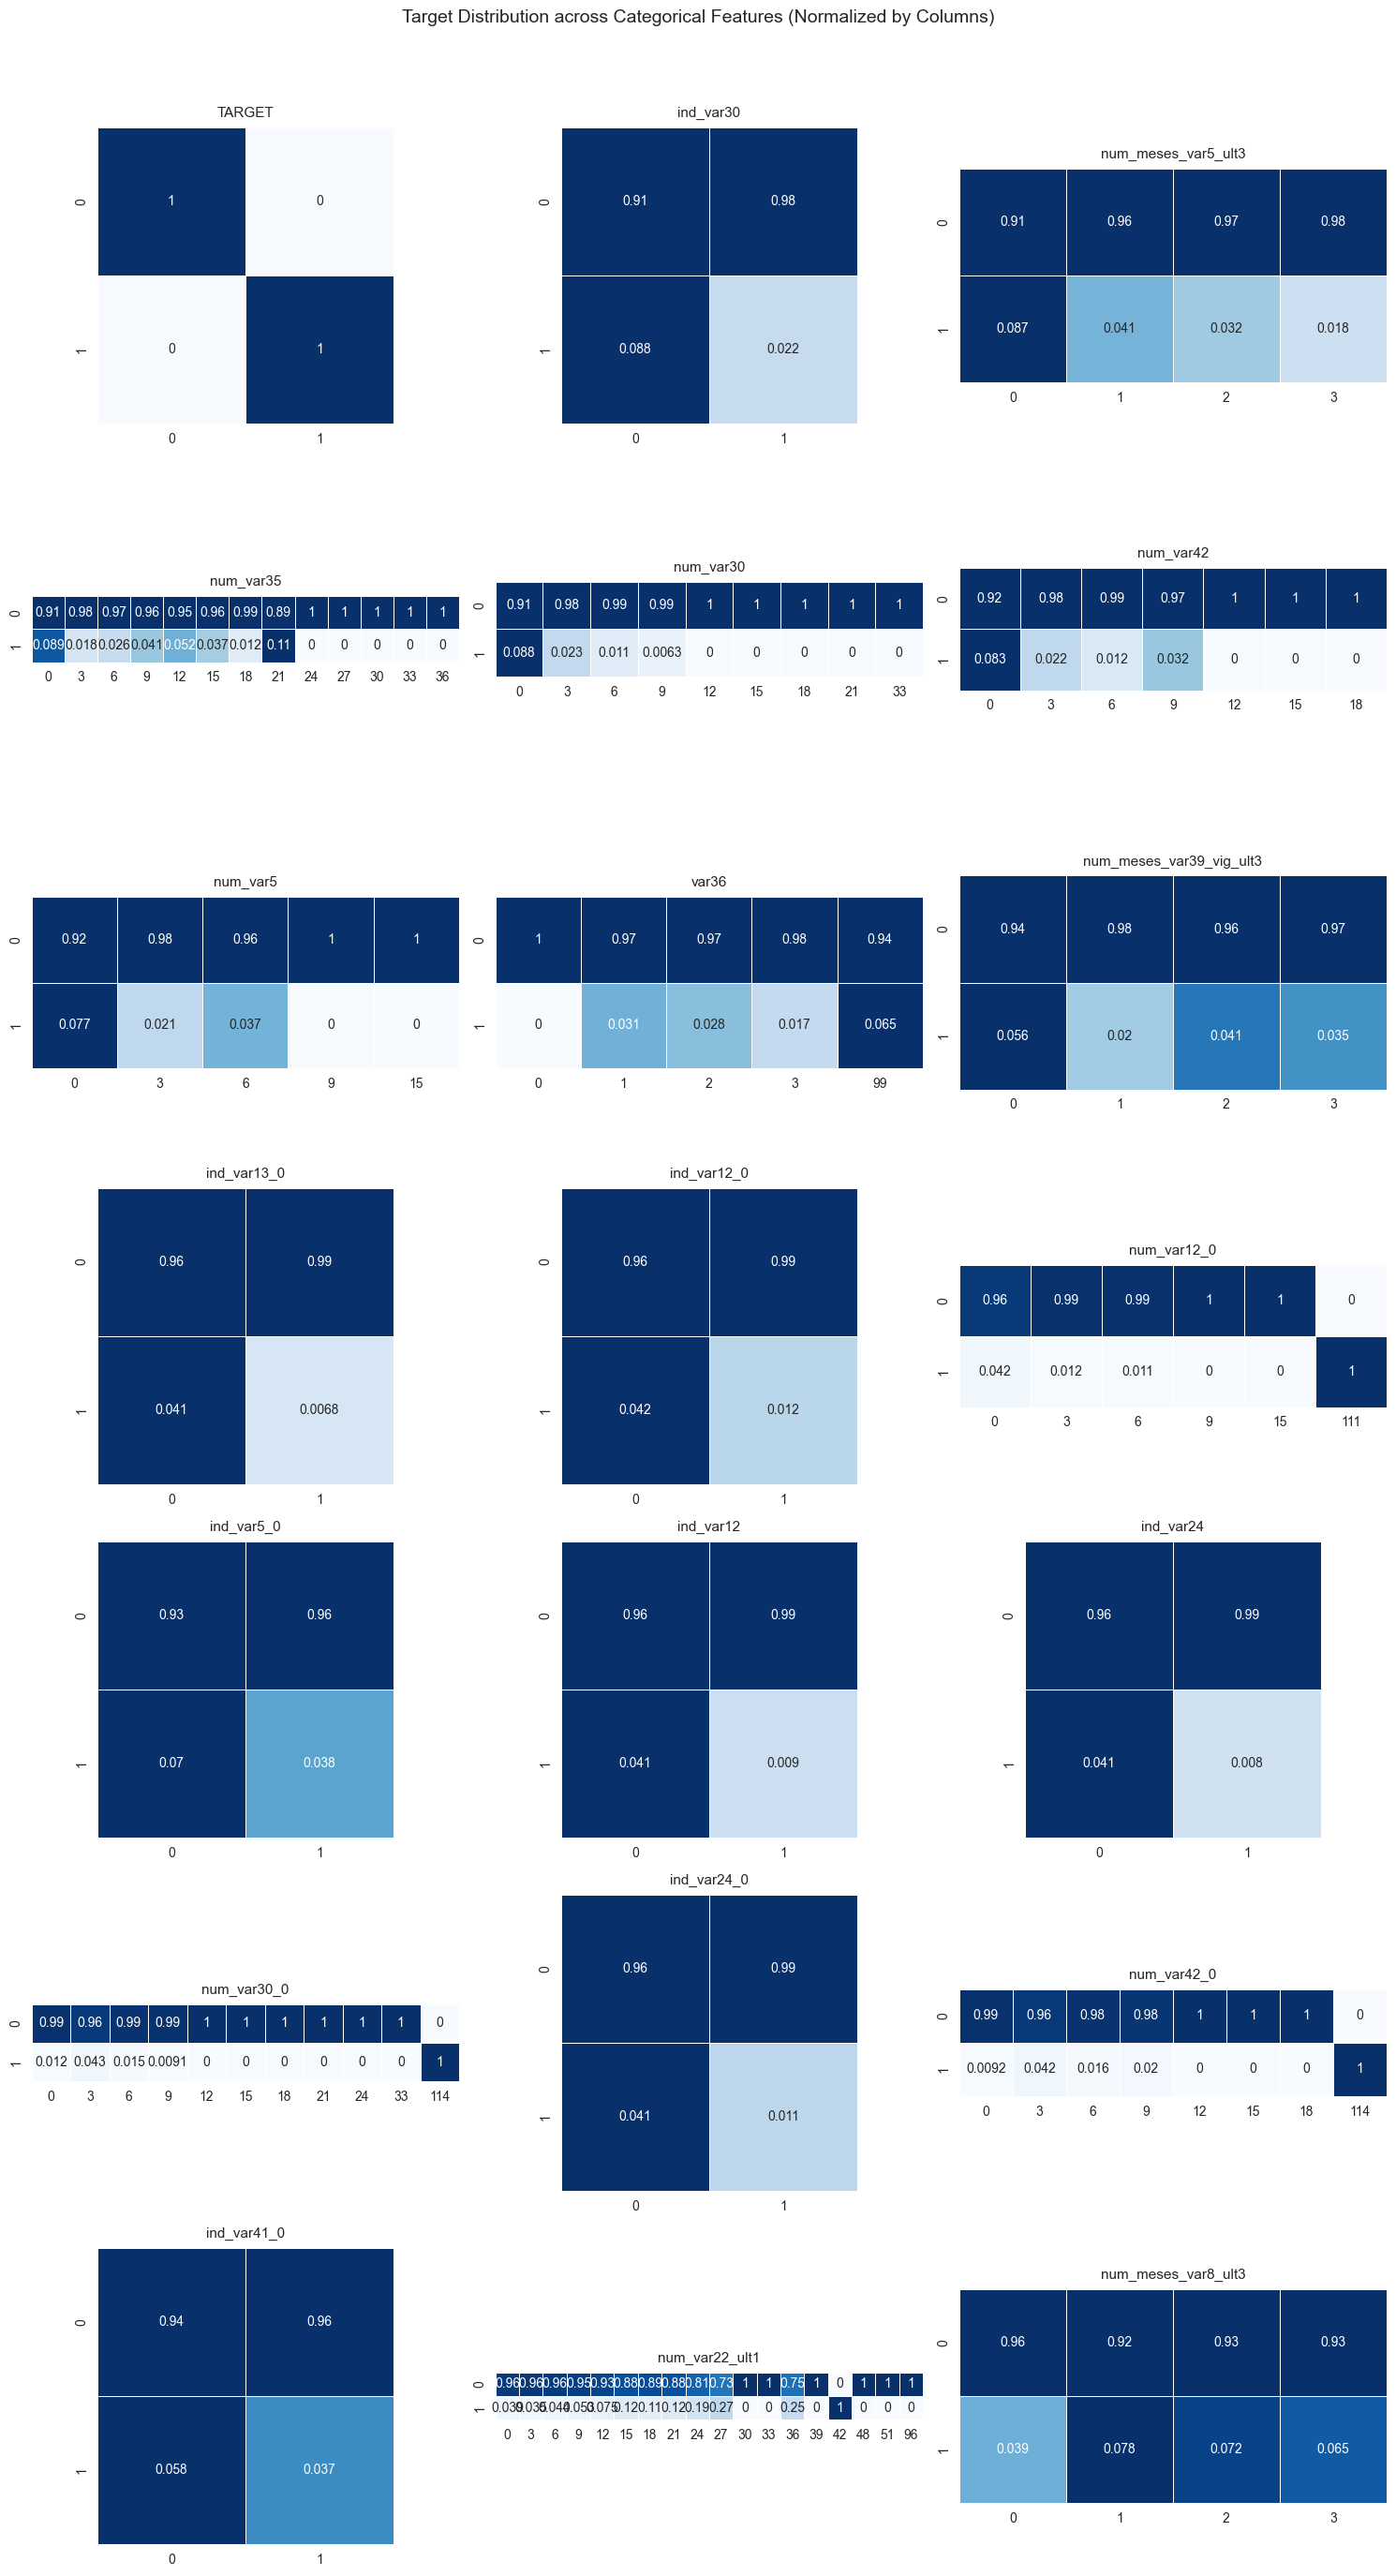

In [32]:
categorical_cols_phik_5p = [i for i in cols_phik_5p_Series.index.to_list() if i in categorical_cols]

plot_categorical_heatmaps_grid(
    df_train,
    categorical_cols=categorical_cols_phik_5p,
    target_col='TARGET',
    ncols=3
)

<div class="alert" style="background-color: #FFFFFF; border-left: 8px solid #1ABC9C; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

Some 'categorical' features seem to have linear dependency with target
</div>

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **Reviewing categorical features**: Calculate Target Concentration and review features
</div>

In [33]:
print("Type of cols_phik_5p:", type(loaded_cols_phik_5p_Series.index.to_list()))
print("Type of categorical_cols:", type(categorical_cols))

Type of cols_phik_5p: <class 'list'>
Type of categorical_cols: <class 'list'>


In [34]:
cols_phik_categorical = [c for c in loaded_cols_phik_5p_Series.index.to_list() if c in categorical_cols]
print("Phik-important categorical columns:", cols_phik_categorical)
print("Number of phik-important categorical columns:", len(cols_phik_categorical))

Phik-important categorical columns: ['TARGET', 'ind_var30', 'num_meses_var5_ult3', 'num_var35', 'num_var30', 'num_var42', 'num_var5', 'var36', 'num_meses_var39_vig_ult3', 'ind_var13_0', 'ind_var12_0', 'num_var12_0', 'ind_var5_0', 'ind_var12', 'ind_var24', 'num_var30_0', 'ind_var24_0', 'num_var42_0', 'ind_var41_0', 'num_var22_ult1', 'num_meses_var8_ult3']
Number of phik-important categorical columns: 21


In [35]:
# Define function that returns a Series
def agg_func(group):
    return pd.Series({
        'count': group['TARGET'].count()
        , 'count_of_target_1_alt': (group['TARGET'] == 1).sum()
        # , 'mean': group['TARGET'].mean()
        , 'mean_pct_target_1': 100 * (group['TARGET'] == 1).sum() / group['TARGET'].count()
    })

# Apply in groupby and style
for col in cols_phik_categorical:
    result : pd.DataFrame = df_train.groupby(col).apply(agg_func).reset_index()
    result["col_value_diff"] = result[col].diff()
    target_concentration_vmin = result['mean_pct_target_1'].min()
    target_concentration_vmax = result['mean_pct_target_1'].max()
    styled = (
        result.style
        .format("{:,.0f}")  # format all numeric columns
        .background_gradient(
            subset=['mean_pct_target_1']
            , cmap='RdYlBu'
            , vmin=target_concentration_vmin
            , vmax=target_concentration_vmax
        )  # color mean_pct_target_1
    )
    display(styled)

,TARGET,count,count_of_target_1_alt,mean_pct_target_1,col_value_diff
0,0,"73,012",0,0,nan
1,1,"3,008","3,008",100,1


,ind_var30,count,count_of_target_1_alt,mean_pct_target_1,col_value_diff
0,0,"20,310","1,786",9,nan
1,1,"55,710","1,222",2,1


,num_meses_var5_ult3,count,count_of_target_1_alt,mean_pct_target_1,col_value_diff
0,0,"20,546","1,783",9,nan
1,1,"3,268",135,4,1
2,2,"9,368",303,3,1
3,3,"42,838",787,2,1


,num_var35,count,count_of_target_1_alt,mean_pct_target_1,col_value_diff
0,0,"19,528","1,737",9,nan
1,3,"37,921",688,2,3
2,6,"12,327",317,3,3
3,9,"4,570",187,4,3
4,12,"1,237",64,5,3
5,15,320,12,4,3
6,18,82,1,1,3
7,21,19,2,11,3
8,24,7,0,0,3
9,27,4,0,0,3


,num_var30,count,count_of_target_1_alt,mean_pct_target_1,col_value_diff
0,0,"20,310","1,786",9,nan
1,3,"51,452","1,179",2,3
2,6,"3,901",41,1,3
3,9,319,2,1,3
4,12,28,0,0,3
5,15,7,0,0,3
6,18,1,0,0,3
7,21,1,0,0,3
8,33,1,0,0,12


...

,ind_var24_0,count,count_of_target_1_alt,mean_pct_target_1,col_value_diff
0,0,"72,799","2,971",4,nan
1,1,"3,221",37,1,1


,num_var42_0,count,count_of_target_1_alt,mean_pct_target_1,col_value_diff
0,0,436,4,1,nan
1,3,"70,242","2,919",4,3
2,6,"5,126",80,2,3
3,9,203,4,2,3
4,12,9,0,0,3
5,15,2,0,0,3
6,18,1,0,0,3
7,114,1,1,100,96


,ind_var41_0,count,count_of_target_1_alt,mean_pct_target_1,col_value_diff
0,0,"9,177",528,6,nan
1,1,"66,843","2,480",4,1


,num_var22_ult1,count,count_of_target_1_alt,mean_pct_target_1,col_value_diff
0,0,"67,953","2,652",4,nan
1,3,"4,832",169,3,3
2,6,"1,829",80,4,3
3,9,734,39,5,3
4,12,320,24,8,3
5,15,174,21,12,3
6,18,76,8,11,3
7,21,40,5,12,3
8,24,21,4,19,3
9,27,15,4,27,3


,num_meses_var8_ult3,count,count_of_target_1_alt,mean_pct_target_1,col_value_diff
0,0,"73,805","2,846",4,nan
1,1,830,65,8,1
2,2,910,66,7,1
3,3,475,31,7,1


<div class="alert" style="background-color: #FFFFFF; border-left: 8px solid #1ABC9C; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

We can now observe, that features that were initially classified as categorical **now appear to be ordinal (or possibly ratio) variables**, since the **difference** between subsequent values **is constant (3)**. This suggests the data **has a meaningful order**, and the target distribution varies in a roughly linear manner with these values, too.

</div>

In [36]:
not_categorical_phik = []
# Apply in groupby and style
for col in cols_phik_categorical:
    result : pd.DataFrame = df_train.groupby(col).apply(agg_func).reset_index()
    result["col_value_diff"] = result[col].diff()
    if (result["col_value_diff"] == 3).any():
        not_categorical_phik.append(col)

not_categorical_phik

['num_var35',
 'num_var30',
 'num_var42',
 'num_var5',
 'num_var12_0',
 'num_var30_0',
 'num_var42_0',
 'num_var22_ult1']

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

Let's review all features, previously classified as categorical ones

</div>

In [37]:
# Define function that returns a Series
def agg_func(group):
    return pd.Series({
        'count': group['TARGET'].count()
        , 'count_of_target_1_alt': (group['TARGET'] == 1).sum()
        # , 'mean': group['TARGET'].mean()
        , 'mean_pct_target_1': 100 * (group['TARGET'] == 1).sum() / group['TARGET'].count()
    })

# Apply in groupby and style
for col in categorical_cols:
    result : pd.DataFrame = df_train.groupby(col).apply(agg_func).reset_index()
    result["col_value_diff"] = result[col].diff()
    target_concentration_vmin = result['mean_pct_target_1'].min()
    target_concentration_vmax = result['mean_pct_target_1'].max()
    styled = (
        result.style
        .format("{:,.0f}")  # format all numeric columns
        .background_gradient(
            subset=['mean_pct_target_1']
            , cmap='RdYlBu'
            , vmin=target_concentration_vmin
            , vmax=target_concentration_vmax
        )  # color mean_pct_target_1
    )
    print("\n",col)
    display(styled)


 num_var13_largo_0


,num_var13_largo_0,count,count_of_target_1_alt,mean_pct_target_1,col_value_diff
0,0,"75,247","3,006",4,nan
1,3,636,2,0,3
2,6,112,0,0,3
3,9,18,0,0,3
4,12,4,0,0,3
5,15,2,0,0,3
6,18,1,0,0,3



 num_var32


,num_var32,count,count_of_target_1_alt,mean_pct_target_1,col_value_diff
0,0,"75,938","3,005",4,nan
1,3,60,2,3,3
2,6,20,1,5,3
3,9,1,0,0,3
4,12,1,0,0,3



 ind_var37_cte


...

,num_med_var22_ult3,count,count_of_target_1_alt,mean_pct_target_1,col_value_diff
0,0,"64,766","2,557",4,nan
1,3,"7,981",273,3,3
2,6,"2,271",95,4,3
3,9,684,45,7,3
4,12,199,20,10,3
5,15,65,12,18,3
6,18,28,2,7,3
7,21,8,0,0,3
8,24,7,2,29,3
9,27,4,1,25,3



 imp_aport_var33_hace3


,imp_aport_var33_hace3,count,count_of_target_1_alt,mean_pct_target_1,col_value_diff
0,0,"75,997","3,008",4,nan
1,150,1,0,0,150
2,300,1,0,0,150
3,900,1,0,0,600
4,"1,500",3,0,0,600
5,"3,000",1,0,0,"1,500"
6,"4,500",1,0,0,"1,500"
7,"6,000",1,0,0,"1,500"
8,"7,500",2,0,0,"1,500"
9,"7,530",1,0,0,30



 TARGET


,TARGET,count,count_of_target_1_alt,mean_pct_target_1,col_value_diff
0,0,"73,012",0,0,nan
1,1,"3,008","3,008",100,1


<div class="alert" style="background-color: #FFFFFF; border-left: 8px solid #1ABC9C; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

With the exception of 'delta_imp_compra_var44_1y3', for all the features listed above, a difference of 3 between consecutive values suggests that the feature is more likely continuous.
</div>

In [38]:
not_categorical = []
# Apply in groupby and style
for col in categorical_cols:
    if col == 'delta_imp_compra_var44_1y3':
        continue
    result : pd.DataFrame = df_train.groupby(col).apply(agg_func).reset_index()
    result["col_value_diff"] = result[col].diff()
    if (result["col_value_diff"] == 3).any():
        not_categorical.append(col)

not_categorical

['num_var13_largo_0',
 'num_var32',
 'num_var37_med_ult2',
 'num_var40',
 'num_trasp_var11_ult1',
 'num_var20_0',
 'num_var13_corto_0',
 'num_var31_0',
 'num_var31',
 'num_aport_var13_ult1',
 'num_var7_recib_ult1',
 'num_op_var41_efect_ult1',
 'num_var25_0',
 'num_op_var40_efect_ult1',
 'num_var30_0',
 'num_var41_0',
 'num_op_var40_hace2',
 'num_var35',
 'num_var17_0',
 'num_var14',
 'num_var14_0',
 'num_aport_var17_ult1',
 'num_var42',
 'num_var5',
 'num_op_var41_hace3',
 'num_var30',
 'num_var44',
 'num_venta_var44_ult1',
 'num_var8_0',
 'num_var22_ult1',
 'num_var17',
 'num_sal_var16_ult1',
 'num_var37_0',
 'num_aport_var17_hace3',
 'num_var5_0',
 'num_var42_0',
 'num_op_var40_efect_ult3',
 'num_var12_0',
 'num_var44_0',
 'num_var22_hace3',
 'num_compra_var44_ult1',
 'num_var22_hace2',
 'num_var20',
 'num_op_var40_hace3',
 'num_aport_var13_hace3',
 'num_ent_var16_ult1',
 'num_var33_0',
 'num_var43_emit_ult1',
 'num_med_var22_ult3']

In [39]:
categorical_cols = [c for c in categorical_cols if c not in not_categorical_phik]
interval_cols = [c for c in df_train.columns if c not in categorical_cols and c != "TARGET"]
with open("../src/features/categorical_columns_list.pkl", "wb") as f:
    pickle.dump(categorical_cols, f)
with open("../src/features/interval_columns_list.pkl", "wb") as f:
    pickle.dump(interval_cols, f)

# load and check
with open("../src/features/categorical_columns_list.pkl", "rb") as f:
    loaded_categorical_cols = pickle.load(f)
with open("../src/features/interval_columns_list.pkl", "rb") as f:
    loaded_interval_cols = pickle.load(f)

print("Loaded categorical columns:", loaded_categorical_cols[:10])
print("Number of loaded categorical columns:", len(loaded_categorical_cols))
print("Loaded interval columns:", loaded_interval_cols[:10])
print("Number of loaded interval columns:", len(loaded_interval_cols))

Loaded categorical columns: ['num_var13_largo_0', 'num_var32', 'ind_var37_cte', 'delta_num_aport_var17_1y3', 'num_var37_med_ult2', 'ind_var24', 'num_var40', 'delta_imp_amort_var34_1y3', 'imp_trasp_var33_in_ult1', 'num_trasp_var11_ult1']
Number of loaded categorical columns: 103
Loaded interval columns: ['Unnamed: 0', 'imp_op_var41_comer_ult3', 'imp_op_var39_ult1', 'imp_aport_var17_ult1', 'imp_reemb_var13_ult1', 'num_var43_recib_ult1', 'imp_trans_var37_ult1', 'num_var45_ult3', 'imp_op_var40_ult1', 'saldo_medio_var13_corto_hace3']
Number of loaded interval columns: 81


<div class="alert" style="background-color: #FFFFFF; border-left: 8px solid #1ABC9C; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

<div class="alert alert-success">

**Manual Feature Review**
</div>

After grouping categorical and discretized numeric features by their unique values and __TARGET__ concentration, I started reviewing them manually to understand which variables provide no useful signal for modeling.  
This allowed me to visually inspect how target concentration behaves across different feature values, especially to detect constant, skewed, or rare-category columns.

<div class="alert alert-info">

**Findings from Manual Inspection**
</div>

After going through several features, here’s what I found:

<div class="alert alert-info">

**Features that should be dropped**
</div>

| Feature                          | Observation                                                                      |
| ------------------------------   | -------------------------------------------------------------------------------- |
| __delta_imp_venta_var44_1y3__    | Constant or near-constant, no variation.                                         |
| __delta_num_aport_var13_1y3__    | Constant or near-constant, no variation.                                         |
| __saldo_medio_var13_medio_ult1__ | Only 3 unique values, 2 appear once.                                             |
| __saldo_medio_var29_ult1__       | 4 unique values, 2 appear once.                                                  |
| __delta_num_trasp_var17_in_1y3__ | 3 unique values, 2 appear only 6 times across dataset.                           |
| __saldo_var29__                  | 3 unique values, 2 appear once.                                                  |
| __imp_trasp_var33_in_hace3__     | 7 unique values, 6 appear once, too sparse.                                      |
| __imp_amort_var18_ult1__         | 3 unique values, 2 appear once.                                                  |
| __delta_imp_reemb_var33_1y3__    | 2 unique values, 1 appears once.                                                 |
| __num_var44__                    | 2 unique values; one occurs 129 times, the other 75,891 times, almost constant.  |
| __imp_aport_var33_hace3__        | Near-constant distribution.                                                      |
| __num_compra_var44_ult1__        | 99.88% zeros; non-zero values → 0 target concentration.                          |
| __num_venta_var44_ult1__         | 99.86% zeros; non-zero values → 0 target concentration.                          |
| __delta_imp_compra_var44_1y3__   | Encoding problems.                                                               |
| __num_var31__                    | Extremely skewed distribution.                                                   |
| __num_var32__                    | 99.89% zeros; all non-zero values show same target rate.                         |
| __num_meses_var13_largo_ult3__   | 99.29% zeros; no target variation across non-zero values.                        |
| __num_var13_largo_0__            | 98.98% zeros; no target variation.                                               |
| __delta_num_trasp_var33_in_1y3__ | 99.98% zeros; other values rare and have zero target signal.                     |


<div class="alert alert-info">

**Features that can be conditionally kept, but they seem to be very weak, too**
</div>

| Feature              | Observation                                                                                                     |
| -------------------- | --------------------------------------------------------------------------------------------------------------- |
| __num_sal_var16_ult1__ | Super-skewed, seems ok for tree-based models. In linear models, may lead to unstable predictions. |
| __ind_var9_cte_ult1__  | Binary feature (69k vs 7k) with ~4% target concentration - potentially weak.              |
| __num_var40_0__        | 98.85% zeros; all values show ~4% target rate, likely weak but stable.                                         |


<div class="alert alert-info">

**Conclusion**
</div>

After manually analyzing a subset of features, the pattern became clear:
many columns are either constant, highly sparse, or super-skewed with no target differentiation.
That means a large portion of them can be safely removed before modeling.

However, since there are **too many features to review manually**, I decided to **automate this analysis**, using a custom function to detect such patterns programmatically.


<div class="alert alert-info">

**Next Step, Automating the Process**
</div>

To speed this up, I created a function that analyzes each feature and provides a concise, human-readable verdict like:

| feature             | verdict      | reason                                  |
| ------------------- | ------------ | --------------------------------------- |
| __feature_x__       | drop         | 3 unique values, almost constant        |
| __feature_y__       | keep         | binary with target difference           |
| __feature_z__       | maybe useful | super-skewed but might help tree models |


<div class="alert" style="background-color:rgb(0, 0, 0); border-left: 8px solid #B12111; padding: 14px; border-radius: 8px; font-size: 14px; color:rgb(255, 255, 255);">

```python
def feature_usefulness_report(df, target_col, categorical_cols, skew_thresh=0.98):
    results = []

    for col in categorical_cols:
        s = df[col]
        n_unique = s.nunique(dropna=False)
        value_counts = s.value_counts(dropna=False)
        top_ratio = value_counts.iloc[0] / len(s)

        # Target concentration per value
        target_mean_by_value = df.groupby(col)[target_col].mean()
        target_std = target_mean_by_value.std(ddof=0)
        target_diff = target_mean_by_value.max() - target_mean_by_value.min()

        # Heuristics
        if n_unique == 1:
            verdict = "drop"
            reason = "constant feature"
        elif top_ratio > skew_thresh:
            if target_diff < 0.02:
                verdict = "drop"
                reason = f"super-skewed ({top_ratio:.2%} same value) with no target variation"
            else:
                verdict = "maybe useful"
                reason = f"super-skewed ({top_ratio:.2%}) but small target difference ({target_diff:.2%})"
        elif n_unique < 3:
            if target_diff < 0.02:
                verdict = "drop"
                reason = f"only {n_unique} unique values and no target variation"
            else:
                verdict = "keep"
                reason = f"binary/ternary variable with target difference ({target_diff:.2%})"
        elif value_counts.iloc[1:].sum() < 0.01 * len(s):
            verdict = "drop"
            reason = f"rare categories dominate, only top value has coverage"
        elif target_std < 0.001:
            verdict = "drop"
            reason = "no variation in target concentration across values"
        else:
            verdict = "keep"
            reason = f"reasonable distribution (top value {top_ratio:.2%}), target difference {target_diff:.2%}"

        results.append({
            "feature": col,
            "n_unique": n_unique,
            "top_value_ratio": round(top_ratio, 4),
            "target_diff": round(target_diff, 4),
            "verdict": verdict,
            "reason": reason
        })

    return pd.DataFrame(results).sort_values("verdict", ascending=True)
```
</div>

I’ll use the function below to automatically evaluate all remaining categorical or discretized numeric columns and generate a feature usefulness report.

</div>

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **Reviewing categorical features - Automated**: 
Review features using custom function from **data_utils.FeaturesUtils.feature_usefulness_report**
</div>

In [40]:
report_df = FeaturesUtils.feature_usefulness_report(df_train, target_col="TARGET", categorical_cols=loaded_categorical_cols)
display(report_df)

display(HTML(report_df.to_html(index=False)))

summary_of_report_df = report_df.groupby("verdict").agg(
    count=("feature", "count")
    , n_unique=("n_unique", "sum")
    , top_value_ratio=("top_value_ratio", "mean")
    , target_diff=("target_diff", "mean")
)
display(summary_of_report_df)

,feature,n_unique,top_value_ratio,target_diff,verdict,reason
59,ind_var43_recib_ult1,2,0.87,0.01,drop,only 2 unique values and no target variation
2,ind_var37_cte,2,0.93,0.00,drop,only 2 unique values and no target variation
64,ind_var1_0,2,0.99,0.00,drop,super-skewed (98.85% same value) with no targe...
50,delta_num_reemb_var13_1y3,2,1.00,0.01,drop,super-skewed (99.95% same value) with no targe...
78,ind_var10_ult1,2,0.92,0.01,drop,only 2 unique values and no target variation
...,...,...,...,...,...,...
34,saldo_medio_var13_medio_ult3,3,1.00,0.04,maybe useful,super-skewed (100.00%) but small target differ...
33,ind_var13_largo_0,2,0.99,0.04,maybe useful,super-skewed (98.98%) but small target differe...
32,delta_num_aport_var33_1y3,4,1.00,0.04,maybe useful,super-skewed (99.98%) but small target differe...
62,num_var17,9,1.00,0.50,maybe useful,super-skewed (99.86%) but small target differe...


feature,n_unique,top_value_ratio,target_diff,verdict,reason
ind_var43_recib_ult1,2,0.87,0.01,drop,only 2 unique values and no target variation
ind_var37_cte,2,0.93,0.00,drop,only 2 unique values and no target variation
ind_var1_0,2,0.99,0.00,drop,super-skewed (98.85% same value) with no target variation
delta_num_reemb_var13_1y3,2,1.00,0.01,drop,super-skewed (99.95% same value) with no target variation
ind_var10_ult1,2,0.92,0.01,drop,only 2 unique values and no target variation
ind_var37_0,2,0.93,0.00,drop,only 2 unique values and no target variation
ind_var9_cte_ult1,2,0.90,0.01,drop,only 2 unique values and no target variation
ind_var43_emit_ult1,2,0.93,0.01,drop,only 2 unique values and no target variation
TARGET,2,0.96,1.00,keep,binary/ternary variable with target difference (100.00%)
num_var25_0,9,0.98,0.27,keep,"reasonable distribution (top value 97.64%), target difference 27.27%"


,count,n_unique,top_value_ratio,target_diff
verdict,,,,
drop,8,16,0.93,0.01
keep,34,294,0.90,0.24
maybe useful,61,433,1.00,0.18


In [41]:
with open("../src/reports/eda_features_report_df.pkl", "wb") as f:
    pickle.dump(report_df, f)
with open("../src/reports/eda_features_report_df.pkl", "rb") as f:
    loaded_report_df = pickle.load(f)
loaded_report_df.sample(5)

,feature,n_unique,top_value_ratio,target_diff,verdict,reason
39,imp_reemb_var17_ult1,20,1.00,1.00,maybe useful,super-skewed (99.97%) but small target differe...
21,num_var31,9,1.00,0.50,maybe useful,super-skewed (99.63%) but small target differe...
57,num_venta_var44_ult1,9,1.00,0.04,maybe useful,super-skewed (99.94%) but small target differe...
49,num_op_var41_hace3,22,0.99,0.17,maybe useful,super-skewed (98.72%) but small target differe...
31,imp_amort_var34_ult1,3,1.00,0.04,maybe useful,super-skewed (100.00%) but small target differ...


<div class="alert" style="background-color:#FFFFFF; border-left: 8px solid #5ad197; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

<div class="alert alert-success">

### **Conclusion**
</div>

The exploratory data analysis (EDA) phase has been successfully completed.  
The following key insights and outcomes were achieved:

- Developed a comprehensive understanding of the dataset’s structure and feature composition.  
- Visualized distributions of both numerical and categorical features, as well as the target variable, revealing important data patterns and imbalances.  
- Identified potential categorical features among numerically encoded variables through heuristic analysis.  
- Calculated and visualized Phik correlations to explore nonlinear relationships between features and the target.  
- Evaluated the usefulness of categorical features based on target concentration metrics and automated feature reports.  
- Categorized features into **useful**, **potentially helpful**, and **redundant/droppable** groups — enabling a more efficient feature selection process for the modeling stage.  

Generated reports and intermediate outputs (including reusable pickle files) have been saved for subsequent analysis and model development.

</div>
